Zápočtový projekt

Jako biologický cíl jsem si vybrala acetylcholinesterázu (AChE), enzym zodpovědný za odbourávání acetylcholinu v nervových synapsích. Jeho inhibitory se klinicky využívají především při léčbě Alzheimerovy choroby (donepezil, rivastigmin, galantamin). Inhibice AChE vede k prodloužení účinku acetylcholinu, což kompenzuje jeho deficit v mozku pacientů s Alzheimerem.
Aktivní látky jsem získala z databáze ChEMBL (target CHEMBL220), konkrétně záznamy s hodnotou IC50.

In [81]:
import csv
from rdkit import Chem
import pandas as pd
import numpy as np
from rdkit import RDLogger

RDLogger.DisableLog('rdApp.*')
from rdkit import DataStructs

## Načtení dat

In [2]:
ache_df = pd.read_csv(
    "chembl_ache_ic50.csv", delimiter=";",
    usecols=["Molecule ChEMBL ID", "Smiles", "Standard Value", "pChEMBL Value"]
)
ache_df.rename(columns={"Molecule ChEMBL ID": "id"}, inplace=True)
ache_df.set_index("id", inplace=True)
ache_df['source'] = 'chembl'

ache_df['Standard Value'] = pd.to_numeric(ache_df['Standard Value'], errors='coerce')
ache_df['pChEMBL Value'] = pd.to_numeric(ache_df['pChEMBL Value'], errors='coerce')

# Parsování SMILES RDKit molekula; None pokud SMILES nelze přečíst
ache_df['mol'] = ache_df['Smiles'].apply(
    lambda x: Chem.MolFromSmiles(x) if isinstance(x, str) else None
)
ache_df.drop(columns=['Smiles'], inplace=True)

print(f"Celkem načtených záznamů: {len(ache_df)}")
print(f"Z toho s platnou pChEMBL hodnotou: {ache_df['pChEMBL Value'].notna().sum()}")
display(ache_df.head())

Celkem načtených záznamů: 9731
Z toho s platnou pChEMBL hodnotou: 6988


,Standard Value,pChEMBL Value,source,mol
id,,,,
CHEMBL1084787,54000.0,4.27,chembl,<rdkit.Chem.rdchem.Mol object at 0x000002194C2...
CHEMBL1084788,60000.0,4.22,chembl,<rdkit.Chem.rdchem.Mol object at 0x000002194C2...
CHEMBL1082434,30.0,7.52,chembl,<rdkit.Chem.rdchem.Mol object at 0x000002194C2...
CHEMBL1084790,12.0,7.92,chembl,<rdkit.Chem.rdchem.Mol object at 0x000002194C2...
CHEMBL102142,77.0,7.11,chembl,<rdkit.Chem.rdchem.Mol object at 0x000002194C2...


In [3]:
chybne = ache_df[ache_df['mol'].isna()]
print(f"Neparsovaných: {len(chybne)}")

ache_df = ache_df[ache_df['mol'].notna()]
print(f"Čistý dataset: {len(ache_df)} molekul")

Neparsovaných: 39
Čistý dataset: 9692 molekul


In [4]:
ache_df['rings'] = ache_df['mol'].apply(lambda x: len(Chem.GetSSSR(x)))
prumer = ache_df['rings'].mean()
print(f"\nPrůměrný počet kruhů: {prumer:.2f}")


Průměrný počet kruhů: 3.62


Průměrný počet kruhů v datasetu AChE inhibitorů leží mezi hodnotou mTOR inhibitorů (4,67) a DrugBank (2,46). AChE inhibitory jsou tedy strukturně komplexnější než průměrné léčivo, ale méně polycyklické než mTOR inhibitory, jejichž vazebné místo vyžaduje objemnější scaffoldy.

Standardizace

In [5]:
from chembl_structure_pipeline import standardizer

ache_df['mol'] = ache_df['mol'].apply(lambda x: standardizer.standardize_mol(x) if x is not None else None)
print(f"Po standardizaci: {ache_df['mol'].notna().sum()} molekul")

Po standardizaci: 9692 molekul


In [6]:
suppl = Chem.SDMolSupplier('../data/drugbank.sdf')
drugbank_df = pd.DataFrame(
    [{"source": "drugbank", "mol": mol, "id": mol.GetProp("DATABASE_ID")} for mol in suppl if mol])
drugbank_df.set_index("id", inplace=True)
drugbank_df

,source,mol
id,,
DB00006,drugbank,<rdkit.Chem.rdchem.Mol object at 0x000002194C2...
DB00014,drugbank,<rdkit.Chem.rdchem.Mol object at 0x000002194C2...
DB00035,drugbank,<rdkit.Chem.rdchem.Mol object at 0x000002194C2...
DB00050,drugbank,<rdkit.Chem.rdchem.Mol object at 0x000002194C2...
DB00091,drugbank,<rdkit.Chem.rdchem.Mol object at 0x000002194C2...
...,...,...
DB13154,drugbank,<rdkit.Chem.rdchem.Mol object at 0x00000219631...
DB13155,drugbank,<rdkit.Chem.rdchem.Mol object at 0x00000219631...
DB13156,drugbank,<rdkit.Chem.rdchem.Mol object at 0x00000219631...


In [7]:
zinc_df = pd.read_csv("../data/zinc_random_structures.txt", delimiter=" ")
zinc_df.rename(columns={"zincid": "id"}, inplace=True)
zinc_df.set_index("id", inplace=True)
zinc_df['source'] = 'zinc'
zinc_df['mol'] = zinc_df['SMILES'].apply(Chem.MolFromSmiles)
zinc_df

,tranche,SMILES,source,mol
id,,,,
ZINCtA000001eUS8,H29P300,CCOC(=O)c1cnc(SC)[nH]c1=N[C@@H]1CC[C@@H]2CN(C(...,zinc,<rdkit.Chem.rdchem.Mol object at 0x00000219631...
ZINCpo00001BLwat,H25P180,CC/C=C\[C@@H](CO)NC(=O)[C@H]1C[C@@H](F)CN1C(=O...,zinc,<rdkit.Chem.rdchem.Mol object at 0x00000219631...
ZINCtz000004JjrO,H29P290,CC(C)CO[C@H](C(=O)N[C@H]1CCN(C(=O)c2cc3c[nH]nc...,zinc,<rdkit.Chem.rdchem.Mol object at 0x00000219631...
ZINCsN000009NpXg,H28P430,O=C(N[C@]12CCC[C@@H]1N(C(=O)C1=C[C@H]3CCC[C@@H...,zinc,<rdkit.Chem.rdchem.Mol object at 0x00000219631...
ZINCsN000009NsBY,H28P430,O=C(N[C@]12CCC[C@H]1N(C(=O)c1cc(Cl)c[nH]1)CC2)...,zinc,<rdkit.Chem.rdchem.Mol object at 0x00000219631...
...,...,...,...,...
ZINCrn00001eRwYj,H27P170,CCc1ncc(C(=O)NCC2CCC(NC(=O)c3ncncc3N)CC2)s1,zinc,<rdkit.Chem.rdchem.Mol object at 0x00000219632...
ZINCsN000009Nrlo,H28P430,O=C(N[C@]12CCC[C@@H]1N(C[C@@H]1CCCCO1)CC2)c1cc...,zinc,<rdkit.Chem.rdchem.Mol object at 0x00000219632...
ZINCtB00000oxE6f,H29P310,Cc1ocnc1C(=O)Nc1cccc(CNC(=O)[C@H](C)n2ccc(C3CC...,zinc,<rdkit.Chem.rdchem.Mol object at 0x00000219632...


In [8]:
structures = pd.concat([drugbank_df, zinc_df, ache_df])
structures.drop(columns=['tranche', 'SMILES'], inplace=True)
structures

,source,mol,Standard Value,pChEMBL Value,rings
id,,,,,
DB00006,drugbank,<rdkit.Chem.rdchem.Mol object at 0x000002194C2...,NaN,NaN,NaN
DB00014,drugbank,<rdkit.Chem.rdchem.Mol object at 0x000002194C2...,NaN,NaN,NaN
DB00035,drugbank,<rdkit.Chem.rdchem.Mol object at 0x000002194C2...,NaN,NaN,NaN
DB00050,drugbank,<rdkit.Chem.rdchem.Mol object at 0x000002194C2...,NaN,NaN,NaN
DB00091,drugbank,<rdkit.Chem.rdchem.Mol object at 0x000002194C2...,NaN,NaN,NaN
...,...,...,...,...,...
CHEMBL5570753,chembl,<rdkit.Chem.rdchem.Mol object at 0x00000219630...,8360.0,5.08,4.0
CHEMBL5565570,chembl,<rdkit.Chem.rdchem.Mol object at 0x00000219630...,5070.0,5.29,4.0
CHEMBL5571784,chembl,<rdkit.Chem.rdchem.Mol object at 0x00000219630...,1620.0,5.79,4.0


In [9]:
structures['mol'] = structures['mol'].apply(lambda x: standardizer.standardize_mol(x) if x is not None else None)
structures

,source,mol,Standard Value,pChEMBL Value,rings
id,,,,,
DB00006,drugbank,<rdkit.Chem.rdchem.Mol object at 0x00000219632...,NaN,NaN,NaN
DB00014,drugbank,<rdkit.Chem.rdchem.Mol object at 0x00000219632...,NaN,NaN,NaN
DB00035,drugbank,<rdkit.Chem.rdchem.Mol object at 0x00000219632...,NaN,NaN,NaN
DB00050,drugbank,<rdkit.Chem.rdchem.Mol object at 0x000002194C2...,NaN,NaN,NaN
DB00091,drugbank,<rdkit.Chem.rdchem.Mol object at 0x000002194C2...,NaN,NaN,NaN
...,...,...,...,...,...
CHEMBL5570753,chembl,<rdkit.Chem.rdchem.Mol object at 0x000002197F1...,8360.0,5.08,4.0
CHEMBL5565570,chembl,<rdkit.Chem.rdchem.Mol object at 0x000002197F1...,5070.0,5.29,4.0
CHEMBL5571784,chembl,<rdkit.Chem.rdchem.Mol object at 0x000002197F1...,1620.0,5.79,4.0


### Deskriptory

In [10]:
from rdkit.Chem import Lipinski, Descriptors, Crippen
from rdkit.Chem import AllChem as Chem
from rdkit.Chem import rdMolDescriptors as rdescriptors
import seaborn as sns
import matplotlib.pyplot as plt

In [11]:
structures['rings'] = structures['mol'].apply(lambda x: len(Chem.GetSSSR(x)))
structures['rotatable'] = structures['mol'].apply(lambda x: rdescriptors.CalcNumRotatableBonds(x))
structures['atoms'] = structures['mol'].apply(lambda x: x.GetNumHeavyAtoms())
structures['hba'] = structures['mol'].apply(lambda x: rdescriptors.CalcNumLipinskiHBA(x))
structures['hbd'] = structures['mol'].apply(lambda x: rdescriptors.CalcNumLipinskiHBD(x))
structures['molwt'] = structures['mol'].apply(lambda x: rdescriptors.CalcExactMolWt(x))
structures['tpsa'] = structures['mol'].apply(lambda x: rdescriptors.CalcTPSA(x))
structures['logp'] = structures['mol'].apply(lambda x: Descriptors.MolLogP(x))


<Axes: xlabel='variable', ylabel='value'>

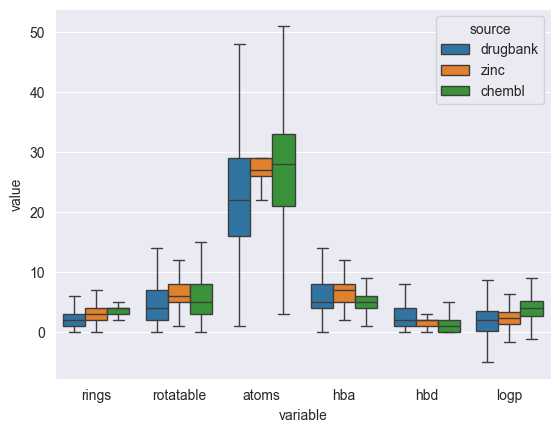

In [12]:
melted = structures.melt(id_vars='source', value_vars=['rings', 'rotatable', 'atoms', 'hba', 'hbd', 'logp'])
sns.boxplot(y='value', x='variable', hue='source', data=melted, showfliers=False)

<Axes: xlabel='variable', ylabel='value'>

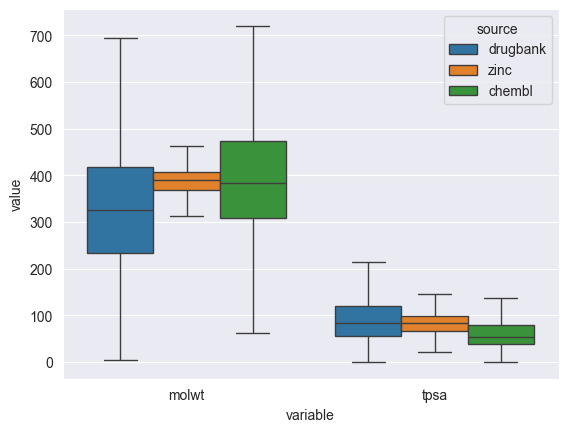

In [13]:
melted2 = structures.melt(id_vars='source', value_vars=['molwt', 'tpsa'])
sns.boxplot(y='value', x='variable', hue='source', data=melted2, showfliers=False)

Vzhledem k tomu, že AChE inhibitory se klinicky využívají k léčbě Alzheimerovy choroby, musí efektivně prostupovat do centrálního nervového systému (CNS). Získaná data to jasně potvrzují:
* LogP (Lipofilicita): AChE inhibitory vykazují posun k vyšším hodnotám LogP (medián kolem 4) oproti DrugBanku (medián kolem 2). Vyšší lipofilicita usnadňuje pasivní difuzi látek přes hematoencefalickou bariéru.
* TPSA (Topologický polární povrch): Polární povrch inhibitorů je výrazně nižší (medián kolem 50–60 $\text{Å}^2$) než u běžných léčiv v DrugBanku. V medicinální chemii je hodnota $\text{TPSA} < 60\text{--}70 \text{ Å}^2$ považována za klasické kritérium pro dobrou penetraci do mozku.
* HBA a HBD (Akceptory a donory vodíkových vazeb): S nízkým TPSA koreluje i nízký počet donorů (medián 1) a akceptorů. Méně polárních skupin znamená, že molekula "neuvízne" v polárních hlavách membránových lipidů.

Aktivní místo acetylcholinesterázy je uloženo na dně hluboké a úzké kavity lemované aromatickými aminokyselinami. Aby molekula dokázala do tohoto místa proniknout a stabilizovat se pomocí $\pi-\pi$ interakcí, potřebuje specifický tvar:
* Počet cyklů a těžkých atomů: Dataset z ChEMBL vykazuje jednoznačně vyšší počet aromatických/alifatických cyklů (medián ~4) a větší počet těžkých atomů než porovnávané sety.
* Molekulová hmotnost (MolWt): V důsledku vyššího počtu cyklů a atomů mají AChE inhibitory vyšší molekulovou hmotnost (medián kolem 380 Da) ve srovnání s průměrem DrugBanku (~320 Da).

<Axes: xlabel='variable', ylabel='value'>

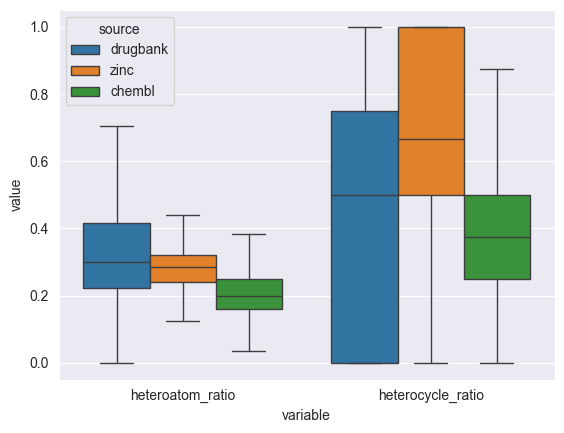

In [14]:
structures['heteroatom_ratio'] = structures['mol'].apply(
    lambda x: rdescriptors.CalcNumHeteroatoms(x) / x.GetNumHeavyAtoms()
)
structures['heterocycle_ratio'] = structures['mol'].apply(
    lambda x: rdescriptors.CalcNumHeterocycles(x) / rdescriptors.CalcNumRings(x)
    if rdescriptors.CalcNumRings(x) > 0 else None
)
melted3 = structures.melt(id_vars='source', value_vars=['heteroatom_ratio', 'heterocycle_ratio'])
sns.boxplot(y='value', x='variable', hue='source', data=melted3, showfliers=False)

* Heteroatom ratio: Inhibitory AChE vykazují prokazatelně nejnižší podíl heteroatomů vůči všem těžkým atomům. Jejich struktura je tedy dominantně tvořena uhlíkovým skeletem.
* Heterocycle ratio: Podíl heterocyklů ku všem cyklům v molekule je u AChE inhibitorů rovněž snížen oproti standardním screeningovým knihovnám.
* Interpretace: Tento trend potvrzuje hypotézu o nutnosti hydrofobního charakteru inhibitorů. Pro interakci s aromatickým chřtánem AChE jsou klíčové čisté aromatické uhlovodíkové kruhy, které nejsou polarizovány přítomností heteroatomů.

## Drug likeness

In [15]:
structures['v_hbd'] = structures['mol'].apply(lambda x: rdescriptors.CalcNumLipinskiHBD(x) > 5)
structures['v_hba'] = structures['mol'].apply(lambda x: rdescriptors.CalcNumLipinskiHBA(x) > 10)
structures['v_mw'] = structures['mol'].apply(lambda x: rdescriptors.CalcExactMolWt(x) > 500)
structures['v_logp'] = structures['mol'].apply(lambda x: Descriptors.MolLogP(x) > 5)
structures['fails_lipinski'] = structures[['v_hbd', 'v_hba', 'v_mw', 'v_logp']].sum(axis=1) > 1


In [16]:
structures['ll_hbd'] = structures['mol'].apply(lambda x: rdescriptors.CalcNumLipinskiHBD(x) > 3)
structures['ll_hba'] = structures['mol'].apply(lambda x: rdescriptors.CalcNumLipinskiHBA(x) > 3)
structures['ll_mw'] = structures['mol'].apply(lambda x: rdescriptors.CalcExactMolWt(x) > 300)
structures['ll_logp'] = structures['mol'].apply(lambda x: Descriptors.MolLogP(x) > 3)
structures['ll_rot'] = structures['mol'].apply(lambda x: Chem.CalcNumRotatableBonds(x) > 3)
structures['fails_lead'] = structures[['ll_hbd', 'll_hba', 'll_mw', 'll_logp', 'll_rot']].sum(axis=1) > 0

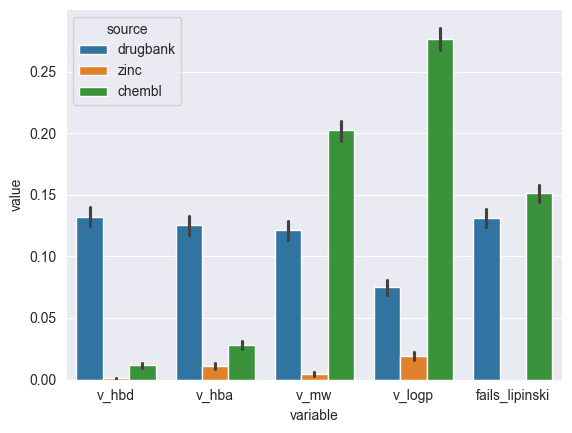

In [17]:
melted_ro5 = structures.melt(id_vars='source', value_vars=['v_hbd', 'v_hba', 'v_mw', 'v_logp', 'fails_lipinski'])
sns.barplot(data=melted_ro5, x='variable', y='value', hue='source')
sns.despine()

Podíl látek, které překračují jednotlivé hraniční parametry (MW > 500, LogP > 5, HBD > 5, HBA > 10).
* Hlavní zjištění: AChE inhibitory nejčastěji porušují kritérium pro lipofilitu (cca 27 % látek) a molekulovou hmotnost (cca 20 % látek).
* Celkové hodnocení: Více než jedno pravidlo Ro5 porušuje přibližně 15 % látek z ChEMBLu. Tento výsledek reflektuje specifické nároky na CNS aktivní látky. Je nutná vysoká lipofilita pro překonání hematoencefalické bariéry. ZINC set jakožto čistě screeningová databáze vykazuje téměř nulové porušení pravidel.

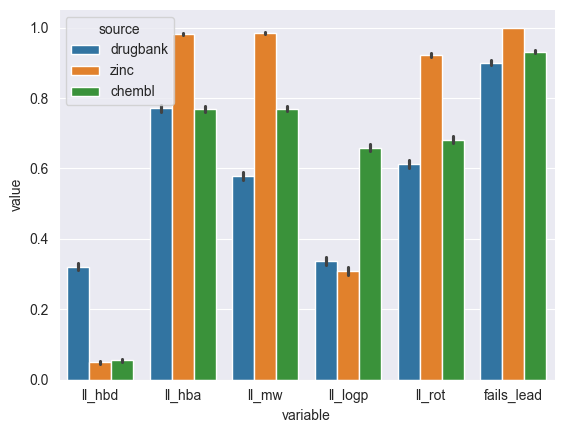

In [18]:
melted_ll = structures.melt(id_vars='source',
                            value_vars=['ll_hbd', 'll_hba', 'll_mw', 'll_logp', 'll_rot', 'fails_lead'])
sns.barplot(data=melted_ll, x='variable', y='value', hue='source')
sns.despine()

Lead-like kritéria jsou nastavena přísněji (např. MW > 300, LogP > 3).
* Výsledky: Téměř 95 % látek v datasetu AChE nesplňuje alespoň jedno z lead-like kritérií.
* Interpretace: Extrémně vysoká míra porušení u parametrů hmotnosti a lipofility jasně demonstruje, že databáze ChEMBL v případě AChE obsahuje finální, strukturně komplexní a plně optimalizované molekuly s vysokou afinitou k cíli, nikoliv jednoduché nízkomolekulární fragmenty.

### Podstruktury


In [19]:
from rdkit.Chem import Draw
from rdkit.Chem.Draw import rdMolDraw2D
from IPython.display import SVG
import itertools
from itertools import chain
from collections import Counter

In [20]:
tertiary_amine = Chem.MolFromSmarts('[NX3;H0]')
ache_mols = list(structures[structures['source'] == 'chembl']['mol'])
drugbank_mols = list(structures[structures['source'] == 'drugbank']['mol'])
zinc_mols = list(structures[structures['source'] == 'zinc']['mol'])

ache_with_tamine = [m for m in ache_mols if m and m.HasSubstructMatch(tertiary_amine)]
db_with_tamine = [m for m in drugbank_mols if m and m.HasSubstructMatch(tertiary_amine)]
zinc_with_tamine = [m for m in zinc_mols if m and m.HasSubstructMatch(tertiary_amine)]

print(
    f"AChE inhibitory s terciálním aminem: {len(ache_with_tamine)} / {len(ache_mols)} ({len(ache_with_tamine) / len(ache_mols):.1%})")
print(
    f"DrugBank s terciálním aminem: {len(db_with_tamine)} / {len(drugbank_mols)} ({len(db_with_tamine) / len(drugbank_mols):.1%})")
print(
    f"Zinc s terciálním aminem: {len(zinc_with_tamine)} / {len(zinc_mols)} ({len(zinc_with_tamine) / len(zinc_mols):.1%})")

AChE inhibitory s terciálním aminem: 5629 / 9692 (58.1%)
DrugBank s terciálním aminem: 2012 / 7120 (28.3%)
Zinc s terciálním aminem: 5242 / 7180 (73.0%)


Terciální amin je přítomen u 58 % AChE inhibitorů, oproti 28 % v DrugBank. Vysoký výskyt odpovídá mechanismu inhibice, kde kladně nabitý dusík interaguje s kationovým vazebným místem AChE. ZINC vykazuje nejvyšší podíl (73 %), což odráží běžné použití aminů v kombinatoriální chemii.

PAINS

In [21]:
pains = []
with open('../data/pains/p_l15.txt', 'r') as f, open('../data/pains/p_m150.txt', 'r') as p:
    for line in chain(f, p):
        pattern, text = line.strip().split('\t')
        pains.append([Chem.MolFromSmarts(pattern),
                      text.lstrip('<regId="').rstrip('">')])


In [22]:
ache_pains_hits = []
for mol in ache_mols:
    if mol:
        hits = [i for i, pain in enumerate(pains) if mol.HasSubstructMatch(pain[0])]
        if hits:
            ache_pains_hits.append((mol, hits))

print(
    f"\nAChE inhibitory s PAINS: {len(ache_pains_hits)} / {len(ache_mols)} ({len(ache_pains_hits) / len(ache_mols):.1%})")
print(f"Po vyfiltrování PAINS zbyde: {len(ache_mols) - len(ache_pains_hits)} molekul")


AChE inhibitory s PAINS: 292 / 9692 (3.0%)
Po vyfiltrování PAINS zbyde: 9400 molekul


In [23]:
all_hits = [pains[i][1] for mol, hits in ache_pains_hits for i in hits]
print("\nNejčastější PAINS vzory:")
for name, count in Counter(all_hits).most_common(5):
    print(f"  {name}: {count}x")


Nejčastější PAINS vzory:
  quinone_A(370): 140x
  anil_di_alk_B(251): 85x
  imine_one_A(321): 18x
  anil_di_alk_C(246): 16x
  azo_A(324): 14x


Pouze 3 % AChE inhibitorů obsahuje PAINS vzory, dataset je tedy relativně čistý. Nejčastější vzor je quinone_A

## Strukturní klíče

In [24]:
from rdkit.Chem import MACCSkeys
from rdkit.Chem.MACCSkeys import smartsPatts

In [25]:
structures['MACCS'] = structures['mol'].apply(lambda x: MACCSkeys.GenMACCSKeys(x) if x else None)

sources = ['chembl', 'drugbank', 'zinc']
maccs_scaled = {}
for source in sources:
    mols_maccs = structures[structures['source'] == source]['MACCS'].dropna().tolist()
    sums = [0] * 167
    for key in mols_maccs:
        for bit in key.GetOnBits():
            sums[bit] += 1
    maccs_scaled[source] = [x / len(mols_maccs) for x in sums]


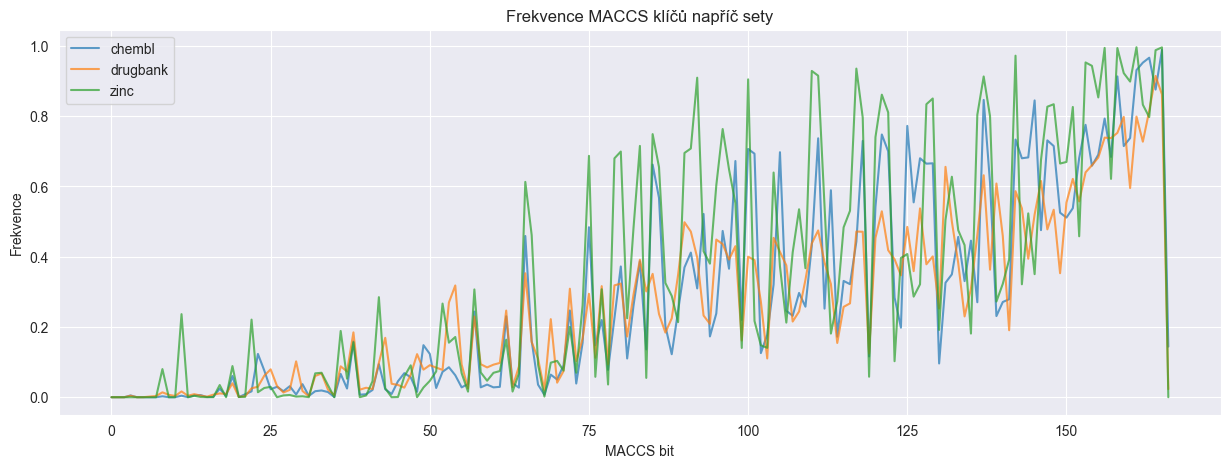

In [26]:
maccs_df = pd.DataFrame(maccs_scaled)
maccs_df.index.name = 'bit'

plt.figure(figsize=(15, 5))
for source, color in zip(sources, ['steelblue', 'orange', 'green']):
    plt.plot(maccs_df[source], alpha=0.7, label=source)
plt.legend()
plt.xlabel('MACCS bit')
plt.ylabel('Frekvence')
plt.title('Frekvence MACCS klíčů napříč sety')
plt.show()

In [85]:
diff = [(i, maccs_scaled['chembl'][i] - maccs_scaled['drugbank'][i]) for i in range(167)]
diff.sort(key=lambda x: x[1])

print("Bity nejčastější v DrugBank oproti AChE (top 5):")
for bit, d in diff[:5]:
    print(f"  bit {bit}: {d:.3f}")

print("\nBity nejčastější v AChE oproti DrugBank (top 5):")
for bit, d in diff[-5:]:
    print(f"  bit {bit}: {d:.3f}")

Bity nejčastější v DrugBank oproti AChE (top 5):
  bit 139: -0.377
  bit 131: -0.330
  bit 54: -0.256
  bit 95: -0.210
  bit 136: -0.191

Bity nejčastější v AChE oproti DrugBank (top 5):
  bit 101: 0.303
  bit 100: 0.307
  bit 85: 0.311
  bit 145: 0.325
  bit 86: 0.331


In [84]:
print("Častější v AChE:")
for bit in [85, 86, 100, 101, 145]:
    print(f"  bit {bit}: {smartsPatts[bit]}")

print("Častější v DrugBank:")
for bit in [139, 131, 54, 95, 136]:
    print(f"  bit {bit}: {smartsPatts[bit]}")

Častější v AChE:
  bit 85: ('[#6]~[#7](~[#6])~[#6]', 0)
  bit 86: ('[C;H2,H3][!#6;!#1][C;H2,H3]', 0)
  bit 100: ('*~[CH2]~[#7]', 0)
  bit 101: ('[$([R]@1@[R]@[R]@[R]@[R]@[R]@[R]@[R]1),$([R]@1@[R]@[R]@[R]@[R]@[R]@[R]@[R]@[R]1),$([R]@1@[R]@[R]@[R]@[R]@[R]@[R]@[R]@[R]@[R]1),$([R]@1@[R]@[R]@[R]@[R]@[R]@[R]@[R]@[R]@[R]@[R]1),$([R]@1@[R]@[R]@[R]@[R]@[R]@[R]@[R]@[R]@[R]@[R]@[R]1),$([R]@1@[R]@[R]@[R]@[R]@[R]@[R]@[R]@[R]@[R]@[R]@[R]@[R]1),$([R]@1@[R]@[R]@[R]@[R]@[R]@[R]@[R]@[R]@[R]@[R]@[R]@[R]@[R]1)]', 0)
  bit 145: ('*1~*~*~*~*~*~1', 1)
Častější v DrugBank:
  bit 139: ('[O;!H0]', 0)
  bit 131: ('[!#6;!#1;!H0]', 1)
  bit 54: ('[!#6;!#1;!H0]~*~*~[!#6;!#1;!H0]', 0)
  bit 95: ('[#7]~*~*~[#8]', 0)
  bit 136: ('[#8]=*', 1)


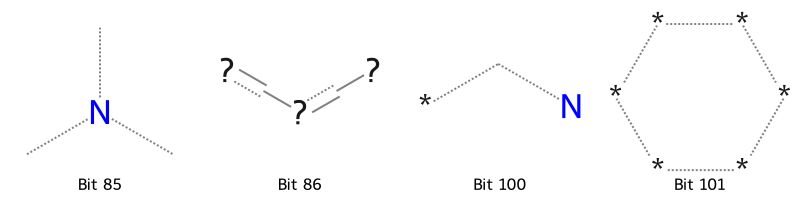

In [93]:
smarts1 = '[#6]~[#7](~[#6])~[#6]'
smarts2 = '[C;H2,H3][!#6;!#1][C;H2,H3]'
smarts3 = '*~[CH2]~[#7]'
smarts4 = '*1~*~*~*~*~*~1'
mol1 = Chem.MolFromSmarts(smarts1)
mol2 = Chem.MolFromSmarts(smarts2)
mol3 = Chem.MolFromSmarts(smarts3)
mol4 = Chem.MolFromSmarts(smarts4)
mols = [mol1, mol2, mol3, mol4]
Draw.MolsToGridImage(mols, molsPerRow=4, subImgSize=(200, 200), legends=['Bit 85', 'Bit 86', 'Bit 100', 'Bit 101'])

AChE inhibitory jsou obohaceny o bity kódující terciální aminy a velké aromatické kruhy (bity 85, 100, 101, 145), což odpovídá nutnosti interagovat s hydrofobní aromatickou kavitou AChE. DrugBank naopak dominuje v bitech pro hydroxylové skupiny a karbonyly (bity 136, 139), což odráží obecně vyšší polaritu schválených léčiv.

### Fingerprity

In [29]:
from rdkit.Chem import AllChem

In [95]:
structures['ECFP4'] = structures['mol'].apply(
    lambda x: AllChem.GetMorganFingerprintAsBitVect(x, 2, nBits=1024) if x else None
)

ecfp_scaled = {}
for source in ['chembl', 'drugbank']:
    fps = structures[structures['source'] == source]['ECFP4'].dropna().tolist()
    sums = [0] * 1024
    for fp in fps:
        for bit in fp.GetOnBits():
            sums[bit] += 1
    ecfp_scaled[source] = [x / len(fps) for x in sums]

diff = [(i, ecfp_scaled['chembl'][i] - ecfp_scaled['drugbank'][i]) for i in range(1024)]
diff.sort(key=lambda x: x[1])

print("Bity nejčastější v DrugBank oproti AChE (top 5):")
for bit, d in diff[:5]:
    print(f"  bit {bit}: {d:.3f}")

print("\nBity nejčastější v AChE oproti DrugBank (top 5):")
for bit, d in diff[-5:]:
    print(f"  bit {bit}: {d:.3f}")

Bity nejčastější v DrugBank oproti AChE (top 5):
  bit 1: -0.204
  bit 147: -0.193
  bit 807: -0.142
  bit 820: -0.129
  bit 233: -0.119

Bity nejčastější v AChE oproti DrugBank (top 5):
  bit 175: 0.227
  bit 64: 0.247
  bit 926: 0.265
  bit 875: 0.275
  bit 726: 0.291


In [98]:
drugbank_bits = [1, 147, 807, 820, 233]
ache_bits = [175, 64, 926, 875, 726]

In [104]:
def substructures_of_bit_ecfp4_1024(mol, bit):
    bitinfo = {}
    AllChem.GetMorganFingerprintAsBitVect(mol, 2, nBits=1024, bitInfo=bitinfo)
    hit_atoms = [Chem.FindAtomEnvironmentOfRadiusN(mol, radius, atom)
                 for atom, radius in bitinfo.get(bit, [])
                 if radius > 0]
    submols = [Chem.PathToSubmol(mol, ha) for ha in hit_atoms]
    return submols


substructure_smiles = {}
for mol in ache_mols:
    for submol in substructures_of_bit_ecfp4_1024(mol, 175):
        smi = Chem.MolToSmiles(submol)
        substructure_smiles[smi] = substructure_smiles.get(smi, 0) + 1

print("Bit 175 ")
substructure_smiles

Bit 175 


{'ccccc': 10467,
 'cc(c)CN(C)C': 50,
 'CC([CH])(C)OC(C)=O': 1,
 'CCC(C(N)=O)N(C)C': 3,
 'cc(c)C(O)CC': 2,
 'CCC(O)C(C)(C)C': 8,
 '[CH]C(C)(C)C(O)CC': 5,
 'cc(c)C(C(N)=O)=C(c)O': 1,
 'ccc(CN)c(c)O': 23,
 '[CH]CN(C)C(C)C': 2,
 'ccc(c(c)C)S(N)(=O)=O': 7,
 'C=C(N)Sc(c)c': 5,
 'cc(Cl)nc(C)n': 1,
 '[CH]C(O)C(C)(C)C(C)C': 1}

In [103]:
substructure_smiles = {}
for mol in ache_mols:
    for submol in substructures_of_bit_ecfp4_1024(mol, 64):
        smi = Chem.MolToSmiles(submol)
        substructure_smiles[smi] = substructure_smiles.get(smi, 0) + 1

print("Bit 64")
substructure_smiles

Bit 64


{'ccc': 14655,
 'cc(C)nc(c)c': 1,
 'CC(=O)O': 16,
 'cc(c)C(=O)n(c)n': 12,
 'ccc(cc)-c(c)[n+]': 8,
 'ccc(Cl)c(c)c': 6,
 '[CH]C(O)OC(C)C': 3,
 '[CH]N([CH])S(=O)(=O)c(c)c': 6,
 'cC(=O)O': 55,
 'cc(c)N(C(C)=O)c(c)c': 18,
 '[CH]C(c)O': 24,
 'C=C(C)O': 2,
 'COC(C)(Oc)C(c)=O': 3,
 '[CH]CC(c(c)c)C(C)N': 4,
 'cc(c)SC(c)C': 7,
 '[CH]C([CH])OC(N)=O': 1,
 'cc(c)-c(co)c(c)=O': 2,
 'CC(C)C': 1,
 'cC(N)O': 2,
 'CC(C)N(C)CC': 2,
 'COc(ns)c(n)N': 1,
 'CC(c)O': 1,
 'CCC(C(C)(C)C)C(C)(C)C': 1,
 'cc(c)C(=O)CC': 1,
 'ccc(c(c)N)c(c)c': 1,
 'C=C(c)O': 1}

In [102]:
substructure_smiles = {}
for mol in ache_mols:
    for submol in substructures_of_bit_ecfp4_1024(mol, 926):
        smi = Chem.MolToSmiles(submol)
        substructure_smiles[smi] = substructure_smiles.get(smi, 0) + 1

print("Bit 926")
substructure_smiles

Bit 926


{'[CH]C([CH])O': 79,
 'CC(C)C': 45,
 'cCCNC': 4,
 'cc(C)cc(c)c': 33,
 'CC(c)C': 37,
 'cC(C)C': 4,
 'cC(c)N': 13,
 'ccc(cc)c(c)[nH]': 12,
 '[CH]C(C)O': 3,
 'CC(c)N': 5,
 'cccnn': 2,
 'CC(C)c': 11,
 'Cc(n)cn(-c)n': 16,
 'cc(C)c(CC)c(c)O': 1,
 '[CH]c(c)c(OC)c(c)c': 1,
 'cncc(C)n': 1,
 '[CH]NC(=O)Cc': 1,
 'CCCNC': 2,
 'cc(C)nc(-c)s': 1,
 'cC(C)N': 1,
 'cc(O)cc(C)n': 1,
 'CCNC(C)C': 4,
 'cc(c)N(C)S(c)(=O)=O': 1,
 'ccc(c(c)N)c(c)n': 6,
 '[CH]CN(CC)C([CH])[CH]': 1,
 'cC=C(SC)C(N)=O': 7,
 'cc(c)C(=O)CC': 1,
 'ccnn(c)C': 1,
 'cc(O)c(C(C)=O)c(c)O': 2,
 'cc(n)CCC': 1,
 'CC(C)OC(C)(C)O': 1,
 'CC(C)N': 1,
 'cc(c)-c(c(c)C)c(-c)n': 2}

In [106]:
substructure_smiles = {}
for mol in ache_mols:
    for submol in substructures_of_bit_ecfp4_1024(mol, 875):
        smi = Chem.MolToSmiles(submol)
        substructure_smiles[smi] = substructure_smiles.get(smi, 0) + 1

print("Bit 875")
substructure_smiles

Bit 875


{'ccc': 7571,
 'CCC(N)(CC)CC': 1,
 'cc(N)c(c(n)O)C(C)c': 33,
 'cc(N)c(c(n)O)C(c)C': 4,
 'cc(N)c(c(n)O)C(c)c': 22,
 'CCCN(C)c': 11,
 'CC(C)CC(N)=O': 19,
 'ccc(-c(n)s)c(c)N': 3,
 'CCS': 43,
 '[CH]NCCN': 2,
 'cc(c)c(C(c)=O)c(-c)s': 1,
 '[CH]OC(=O)C(C)C': 7,
 'CC(=O)NC(C)C': 4,
 'cc(O)c(c(c)c)c(c)o': 2,
 'cc(Cl)c(c(c)Cl)C(N)N': 1,
 'CCCN(c)C': 2,
 'CCC(CC)CC': 4,
 '[CH]N=C(NC)C(C)C': 1,
 'cn[nH]c(c)N': 3,
 'cn[nH]c(c)-c': 2,
 'cnc(c(c)C)c(c)n': 1}

In [107]:
substructure_smiles = {}
for mol in ache_mols:
    for submol in substructures_of_bit_ecfp4_1024(mol, 726):
        smi = Chem.MolToSmiles(submol)
        substructure_smiles[smi] = substructure_smiles.get(smi, 0) + 1

print("Bit 726")
substructure_smiles

Bit 726


{'ccc': 31364,
 'cc(c)CCC': 22,
 'ccc(O)c(c)-c': 4,
 'cc(N)cn(c)c': 1,
 'CCC(NC)C(N)=O': 15,
 'CN(C)C': 19,
 'ccc(c[n+])c(c)c': 45,
 'ccsc(c)C': 3,
 '[CH]C([CH])(C)CN(C)C': 1,
 'CCSc(c)c': 27,
 'c[se]n(c(c)=O)C(C)C': 4,
 '[CH]N(C)C': 3,
 'cc[n+](C)cc': 1,
 'cc(=S)n(CC)c(C)n': 1,
 'C=Cc(c(c)c)c(c)c': 1,
 'cc(-n)cc(c)O': 3,
 'cc(c)C(C(=O)O)=C(c)C': 1,
 'ccc(oc)c(c)c': 6,
 'cc(c)NCC': 1,
 'cc(N)cc(c)O': 1,
 'CC(C)C(C(=C)O)=C(C)O': 1}

Vysoké zastoupení bitů reprezentujících aromatické kruhy (ccc) v AChE sadě souvisí s nezbytnou kation-$\pi$ interakcí. Fragmenty typu [CH]C([CH])O naznačují přítomnost specifických hydrofobních alifatických větvení.

### Similarity search

In [34]:
def tanimoto(vector1, vector2):
    set_bits = 0
    shared_bits = 0
    for bit1, bit2 in zip(vector1, vector2):
        if bit1 or bit2:
            set_bits += 1
            if bit1 and bit2:
                shared_bits += 1
    return shared_bits / set_bits

In [35]:
def similarity_search(query_fp, searched_fp_set, cutoff=0.8):
    hits = []
    for i, fp in enumerate(searched_fp_set):
        similarity = DataStructs.TanimotoSimilarity(query_fp, fp)
        if similarity >= cutoff:
            hits.append((i, similarity))
    return sorted(hits, key=lambda x: x[1], reverse=True)

In [36]:
ache_fps = list(structures[structures['source'] == 'chembl']['ECFP4'].dropna())
drugbank_fps = list(structures[structures['source'] == 'drugbank']['ECFP4'].dropna())
zinc_fps = list(structures[structures['source'] == 'zinc']['ECFP4'].dropna())
drugbank_mols = list(structures[structures['source'] == 'drugbank']['mol'].dropna())
zinc_mols = list(structures[structures['source'] == 'zinc']['mol'].dropna())
ache_mols = list(structures[structures['source'] == 'chembl']['mol'].dropna())


In [37]:
ache_vs_drugbank = [(i, similarity_search(fp, drugbank_fps))
                    for i, fp in enumerate(ache_fps)]
ache_hits_db = [hit for hit in ache_vs_drugbank if hit[1]]

In [38]:
print(f"AChE inhibitory s podobnou molekulou v DrugBank: ({len(ache_hits_db) / len(ache_fps):.1%})")

AChE inhibitory s podobnou molekulou v DrugBank: (15.4%)


In [39]:
ache_vs_zinc = [(i, similarity_search(fp, zinc_fps, cutoff=0.5))
                for i, fp in enumerate(ache_fps)]
ache_hits_zinc = [hit for hit in ache_vs_zinc if hit[1]]

print(f"AChE inhibitory s podobnou molekulou v ZINCu: {len(ache_hits_zinc)} / {len(ache_fps)}")

AChE inhibitory s podobnou molekulou v ZINCu: 0 / 9692


In [82]:
db_names = {}
suppl_names = Chem.SDMolSupplier('../data/drugbank.sdf')
for mol in suppl_names:
    if mol is None:
        continue
    db_id = mol.GetProp('DATABASE_ID')
    name = mol.GetProp('GENERIC_NAME') if mol.HasProp('GENERIC_NAME') else 'neznámý'
    db_names[db_id] = name

In [83]:
ache_fps = list(structures[structures['source'] == 'chembl']['ECFP4'].dropna())
ache_ids = list(structures[structures['source'] == 'chembl']['ECFP4'].dropna().index)
drugbank_fps_list = list(structures[structures['source'] == 'drugbank']['ECFP4'].dropna())
drugbank_ids = list(structures[structures['source'] == 'drugbank']['ECFP4'].dropna().index)

results = []
for ache_id, ache_fp in zip(ache_ids, ache_fps):
    sims = [DataStructs.TanimotoSimilarity(ache_fp, db_fp)
            for db_fp in drugbank_fps_list]
    best_idx = int(np.argmax(sims))
    best_sim = sims[best_idx]
    results.append({
        'ache_id': ache_id,
        'db_id': drugbank_ids[best_idx],
        'tanimoto': best_sim
    })

results_df = pd.DataFrame(results).sort_values('tanimoto', ascending=False)
results_df['db_name'] = results_df['db_id'].map(db_names)

print("\nTop 20 AChE inhibitorů nejpodobnějších DrugBanku:")
print(results_df[['ache_id', 'db_id', 'db_name', 'tanimoto']].head(20).to_string(index=False))


Top 20 AChE inhibitorů nejpodobnějších DrugBanku:
      ache_id   db_id                     db_name  tanimoto
CHEMBL1908847 DB06727                   Sparteine       1.0
    CHEMBL407 DB01205                  Flumazenil       1.0
    CHEMBL888 DB00441                 Gemcitabine       1.0
   CHEMBL1349 DB00577                Valaciclovir       1.0
CHEMBL1082738 DB04616 TACRINE(8)-4-AMINOQUINOLINE       1.0
 CHEMBL475534 DB01054                Nitrendipine       1.0
    CHEMBL165 DB02709                 Resveratrol       1.0
     CHEMBL95 DB00382                     Tacrine       1.0
CHEMBL1084775 DB04616 TACRINE(8)-4-AMINOQUINOLINE       1.0
 CHEMBL426123 DB01041                 Thalidomide       1.0
  CHEMBL74926 DB04892                  Phenserine       1.0
   CHEMBL1544 DB00279                Liothyronine       1.0
 CHEMBL278819 DB00805                   Minaprine       1.0
    CHEMBL832 DB01138              Sulfinpyrazone       1.0
     CHEMBL41 DB00472                  Fluoxetine

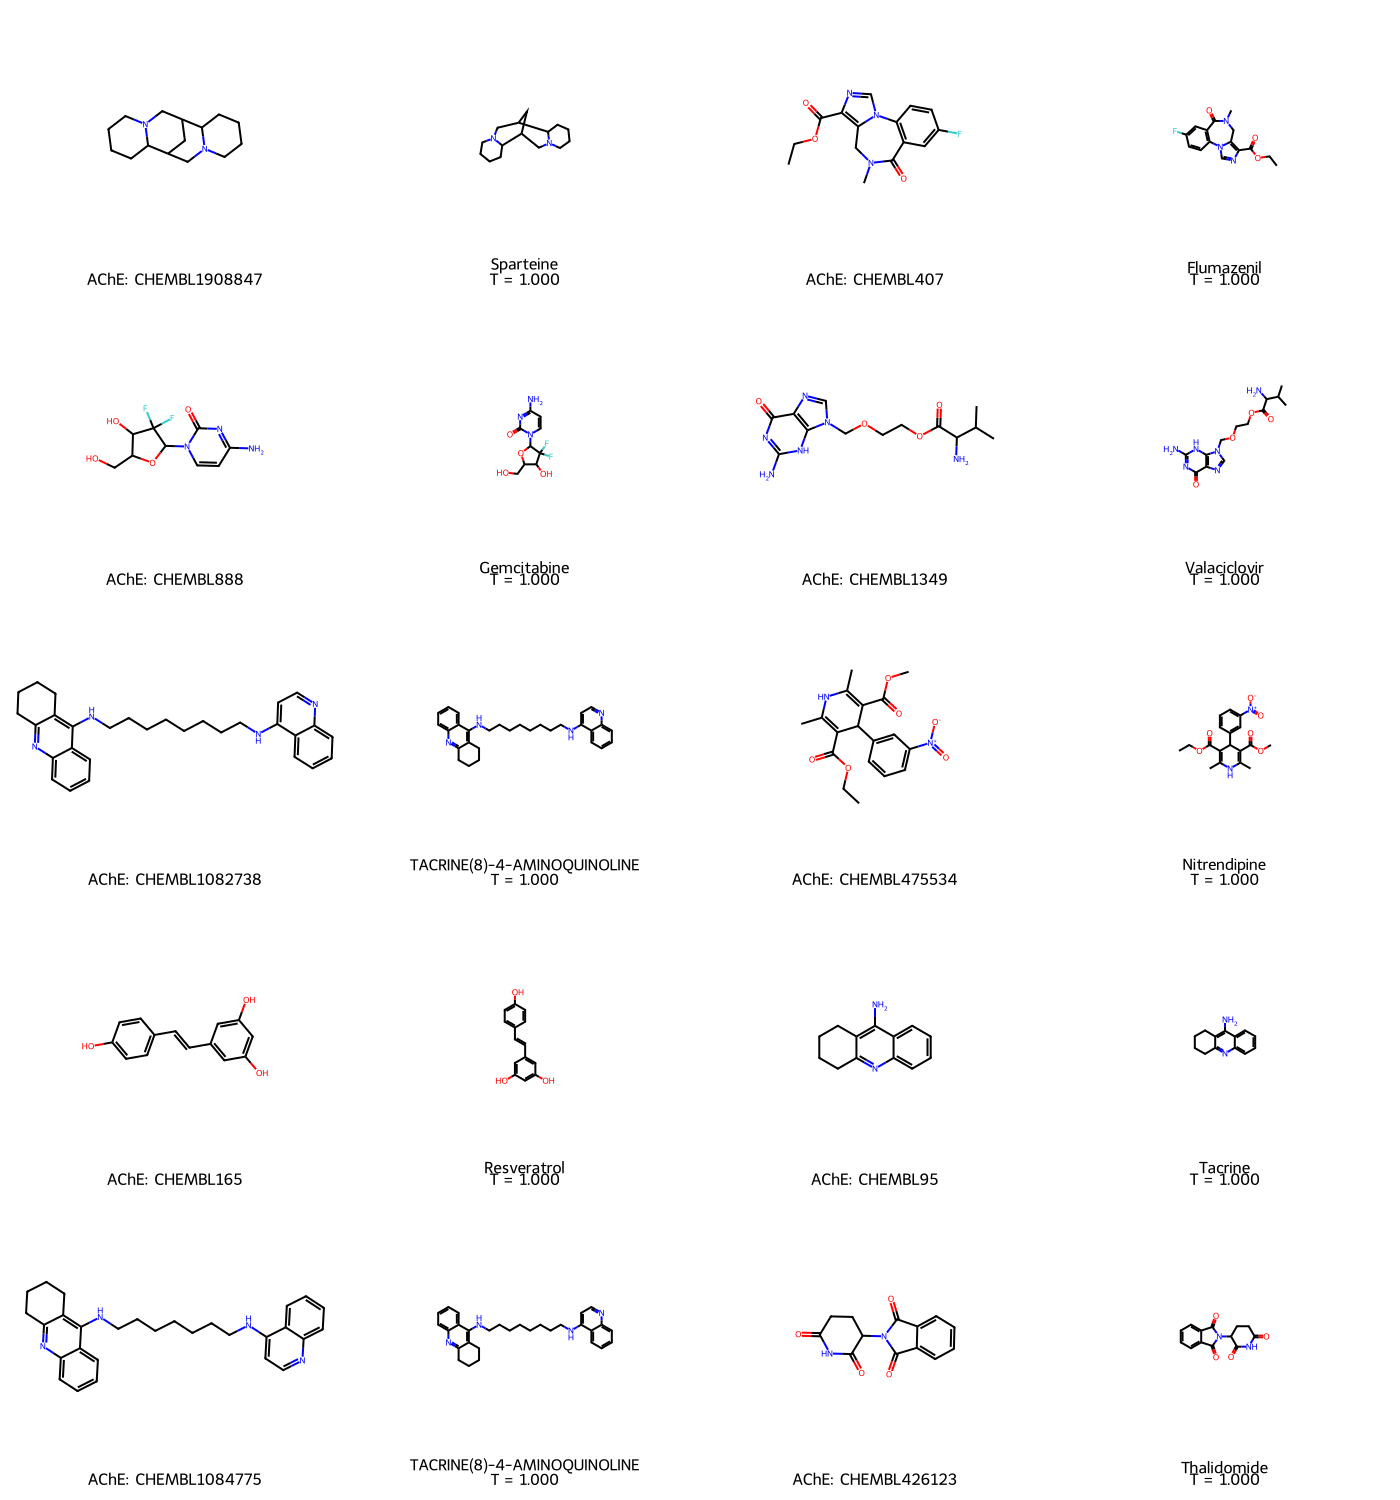

In [109]:
# Nakreslím páry s názvy z DrugBanku
top10 = results_df.head(10)

pairs = []
legends = []
for _, row in top10.iterrows():
    mol_ache = structures.loc[row['ache_id'], 'mol']
    mol_db = structures.loc[row['db_id'], 'mol']

    # Vezmeme název ze sloupce 'db_name', pokud chybí, použijeme db_id
    db_name = row['db_name'] if pd.notna(row['db_name']) else row['db_id']

    pairs.extend([mol_ache, mol_db])
    legends.extend([
        f"AChE: {row['ache_id']}",
        f"{db_name}\nT = {row['tanimoto']:.3f}"
    ])

Draw.MolsToGridImage(pairs, molsPerRow=4, subImgSize=(350, 300), legends=legends)

Analýza podobnosti ukázala, že řada látek testovaných proti AChE v ChEMBL jsou již schválená léčiva z databáze DrugBank. Mezi nimi se nacházejí přímé inhibitory AChE využívané v terapii Alzheimerovy choroby, jako je Tacrine a jeho deriváty, či Phenserine. Zásadním zjištěním je však stoprocentní shoda s léčivy z úplně jiných indikačních skupin, jako je Memantine (antagonista NMDA receptorů pro Alzheimerovu chorobu, často podávaný v kombinaci s inhibitory AChE), Fluoxetine (antidepresivum Prozac) nebo blokátory vápníkových kanálů (Nitrendipine, Felodipine). Tyto výsledky jasně potvrzují, že koncept hledání nových aplikací pro již známá léčiva (drug repurposing) je u acetylcholinesterázy vysoce relevantní, přičemž tyto látky mohou vykazovat duální mechanismus účinku nebo poskytovat dodatečný neuroprotektivní efekt.

Diversity picking

In [40]:
from rdkit.SimDivFilters.rdSimDivPickers import MaxMinPicker

In [41]:
def distance_function(index1, index2, *args, fingerprints=ache_fps,
                      metric=DataStructs.TanimotoSimilarity):
    return 1 - DataStructs.FingerprintSimilarity(fingerprints[index1],
                                                 fingerprints[index2],
                                                 metric=metric)


In [42]:
n_pick = max(20, len(ache_fps) // 100)
picker = MaxMinPicker()
picked = list(picker.LazyPick(distance_function, len(ache_fps), n_pick))


C:\Projects\PNL\cdd2026\pnl\Lib\site-packages\rdkit\Chem\Draw\IPythonConsole.py:376: UserWarning: Truncating the list of molecules to be displayed to 50. Change the maxMols value to display more.
  warnings.warn(


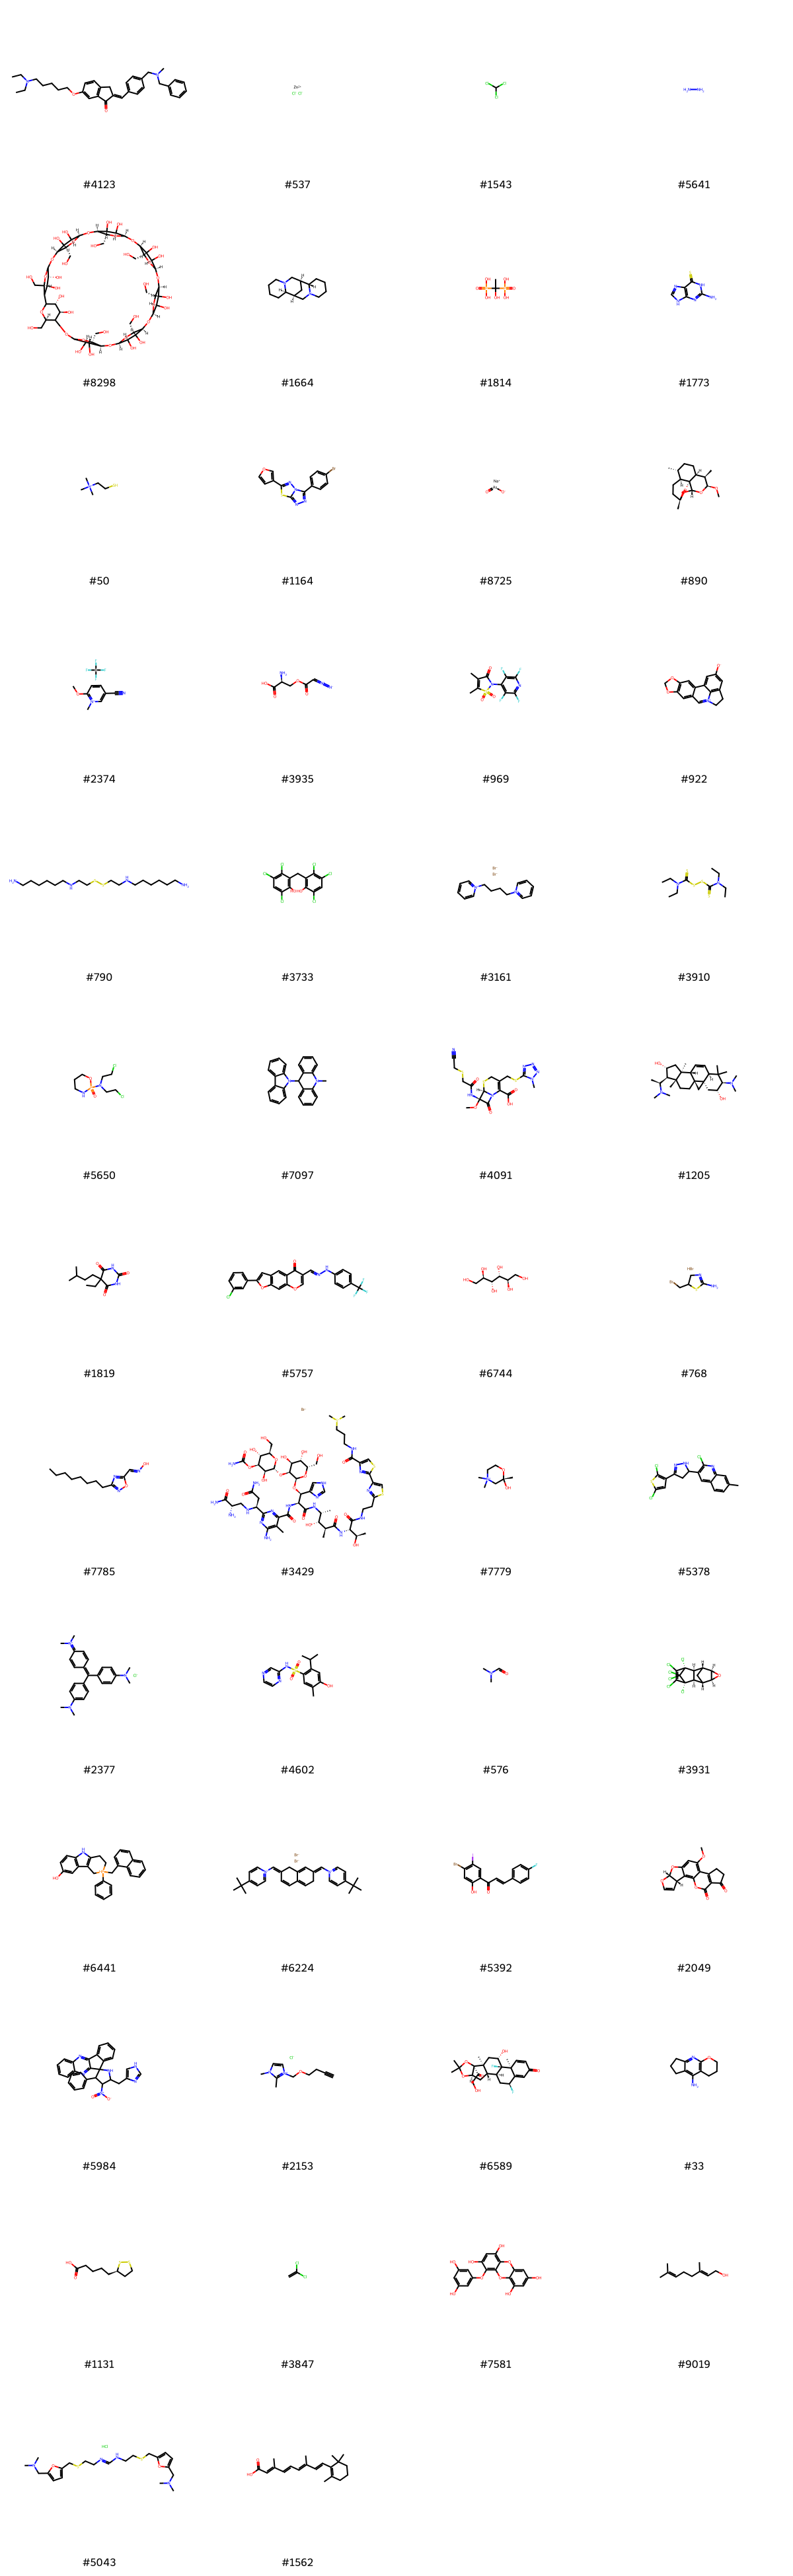

In [43]:
Draw.MolsToGridImage(
    [ache_mols[i] for i in picked],
    molsPerRow=4, subImgSize=(300, 300),
    legends=[f"#{i}" for i in picked]
)

- Vybrané struktury pokrývají velmi široké spektrum chemického prostoru
od jednoduchých alifatických fragmentů přes bicyklické
a tricyklické systémy až po makrocyklické struktury.

- Subset neobsahuje dominantní strukturní motiv, každá další vybraná molekula
se skutečně výrazně liší od předchozích. To nasvědčuje tomu, že dataset
AChE inhibitorů z ChEMBL je strukturně diverzní.

- Přítomnost velmi jednoduchých fragmentů a alifatických řetězců na začátku výběru
naznačuje, že dataset obsahuje i molekuly vzdálené od typického farmakoforu
AChE inhibitorů.

## Scaffold

In [44]:
from rdkit.Chem.Scaffolds import MurckoScaffold

In [45]:
def scaffold(mol):
    Chem.rdmolops.RemoveStereochemistry(mol)
    try:
        scaff = MurckoScaffold.MakeScaffoldGeneric(mol)
    except ValueError:
        return None
    scaff = MurckoScaffold.GetScaffoldForMol(scaff)
    return scaff

In [46]:
ache_scaffolds_smiles = [(i, Chem.MolToSmiles(scaffold(mol)))
                         for i, mol in enumerate(ache_mols) if scaffold(mol)]
scaffolds2ligands = {smi: [] for i, smi in ache_scaffolds_smiles}
for i, smi in ache_scaffolds_smiles:
    scaffolds2ligands[smi].append(i)

scaffold_ligandcount = [(smi, len(ligs)) for smi, ligs in scaffolds2ligands.items()]
scaffold_ligandcount.sort(key=lambda x: x[1], reverse=True)

print(f"Celkem unikátních scaffoldů: {len(scaffold_ligandcount)}")
print(f"Top 5 nejčastějších scaffoldů:")
for smi, count in scaffold_ligandcount[:5]:
    print(f"  {count} ligandů: {smi}")

Celkem unikátních scaffoldů: 1764
Top 5 nejčastějších scaffoldů:
  516 ligandů: C1CCCCC1
  430 ligandů: C1CCC2CC3CCCCC3CC2C1
  270 ligandů: C1CCC(CC2CCC(CC3CC4CCCCC4C3)CC2)CC1
  180 ligandů: C1CCC2C(C1)CC1CCCC12
  159 ligandů: C1CCC2CCCC2C1


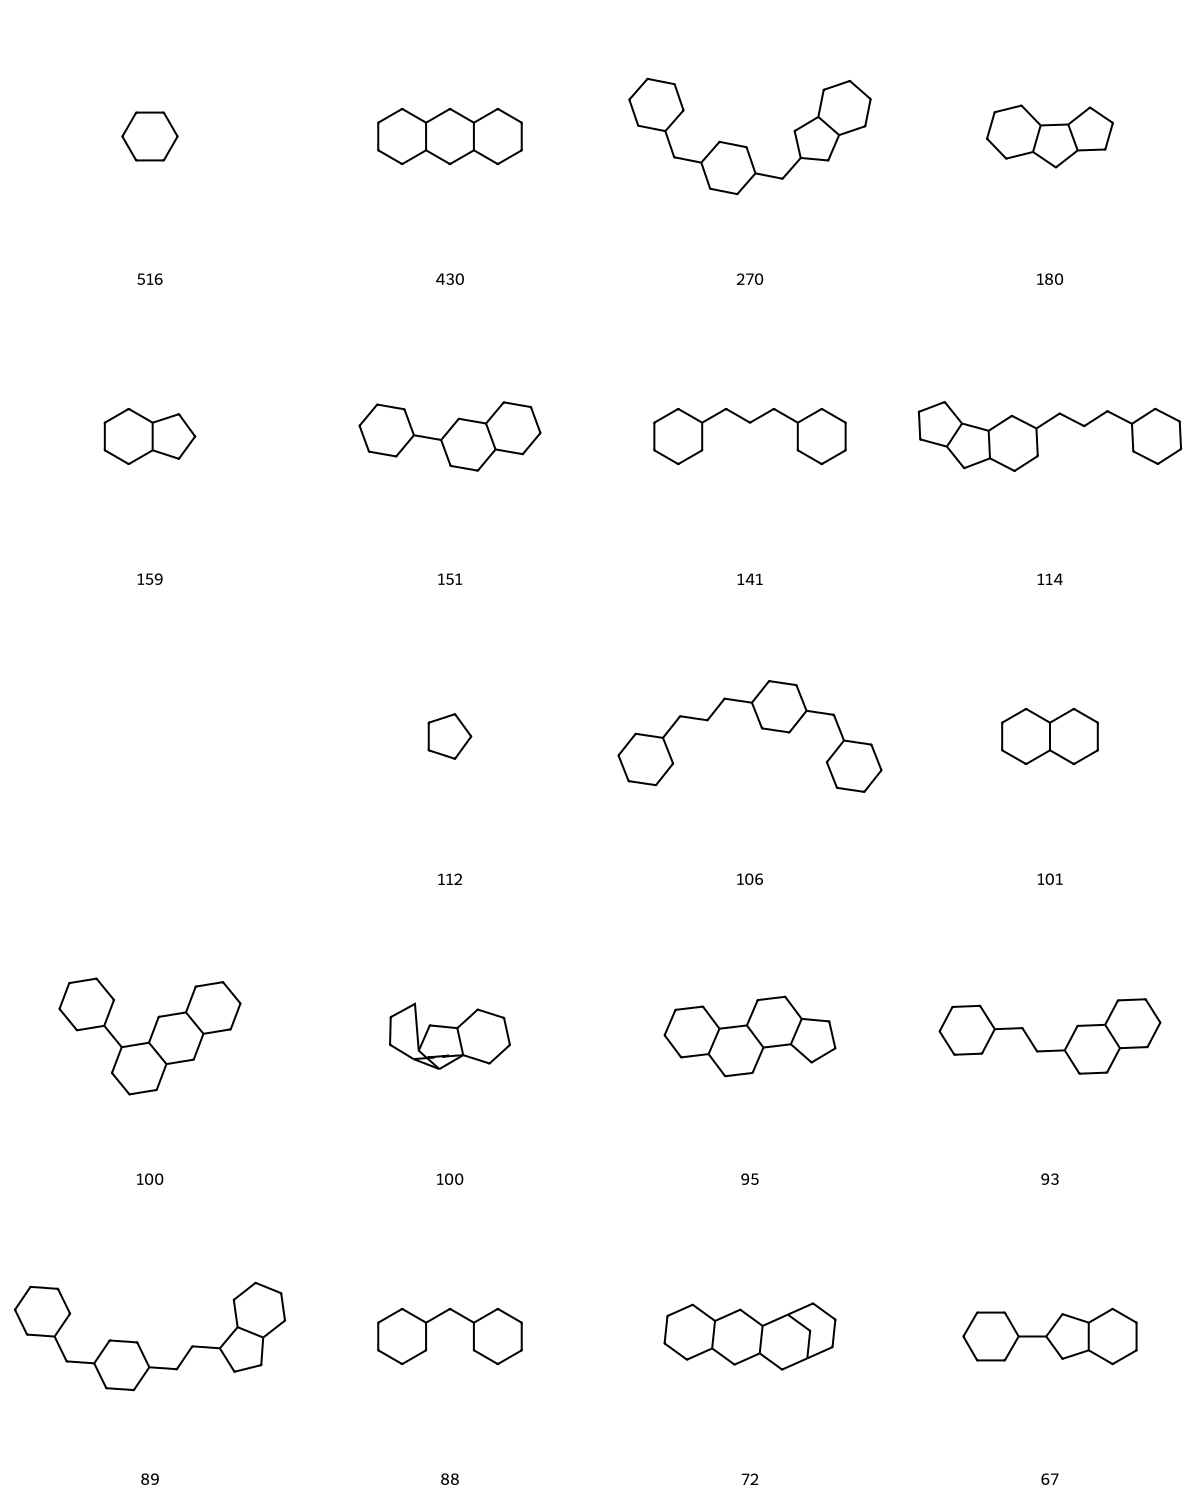

In [47]:
Draw.MolsToGridImage(
    [Chem.MolFromSmiles(smi) for smi, count in scaffold_ligandcount[:20]],
    molsPerRow=4, subImgSize=(300, 300),
    legends=[str(count) for smi, count in scaffold_ligandcount[:20]]
)

In [48]:
scaffold_representatives = {smi: ligs[0] for smi, ligs in scaffolds2ligands.items()}


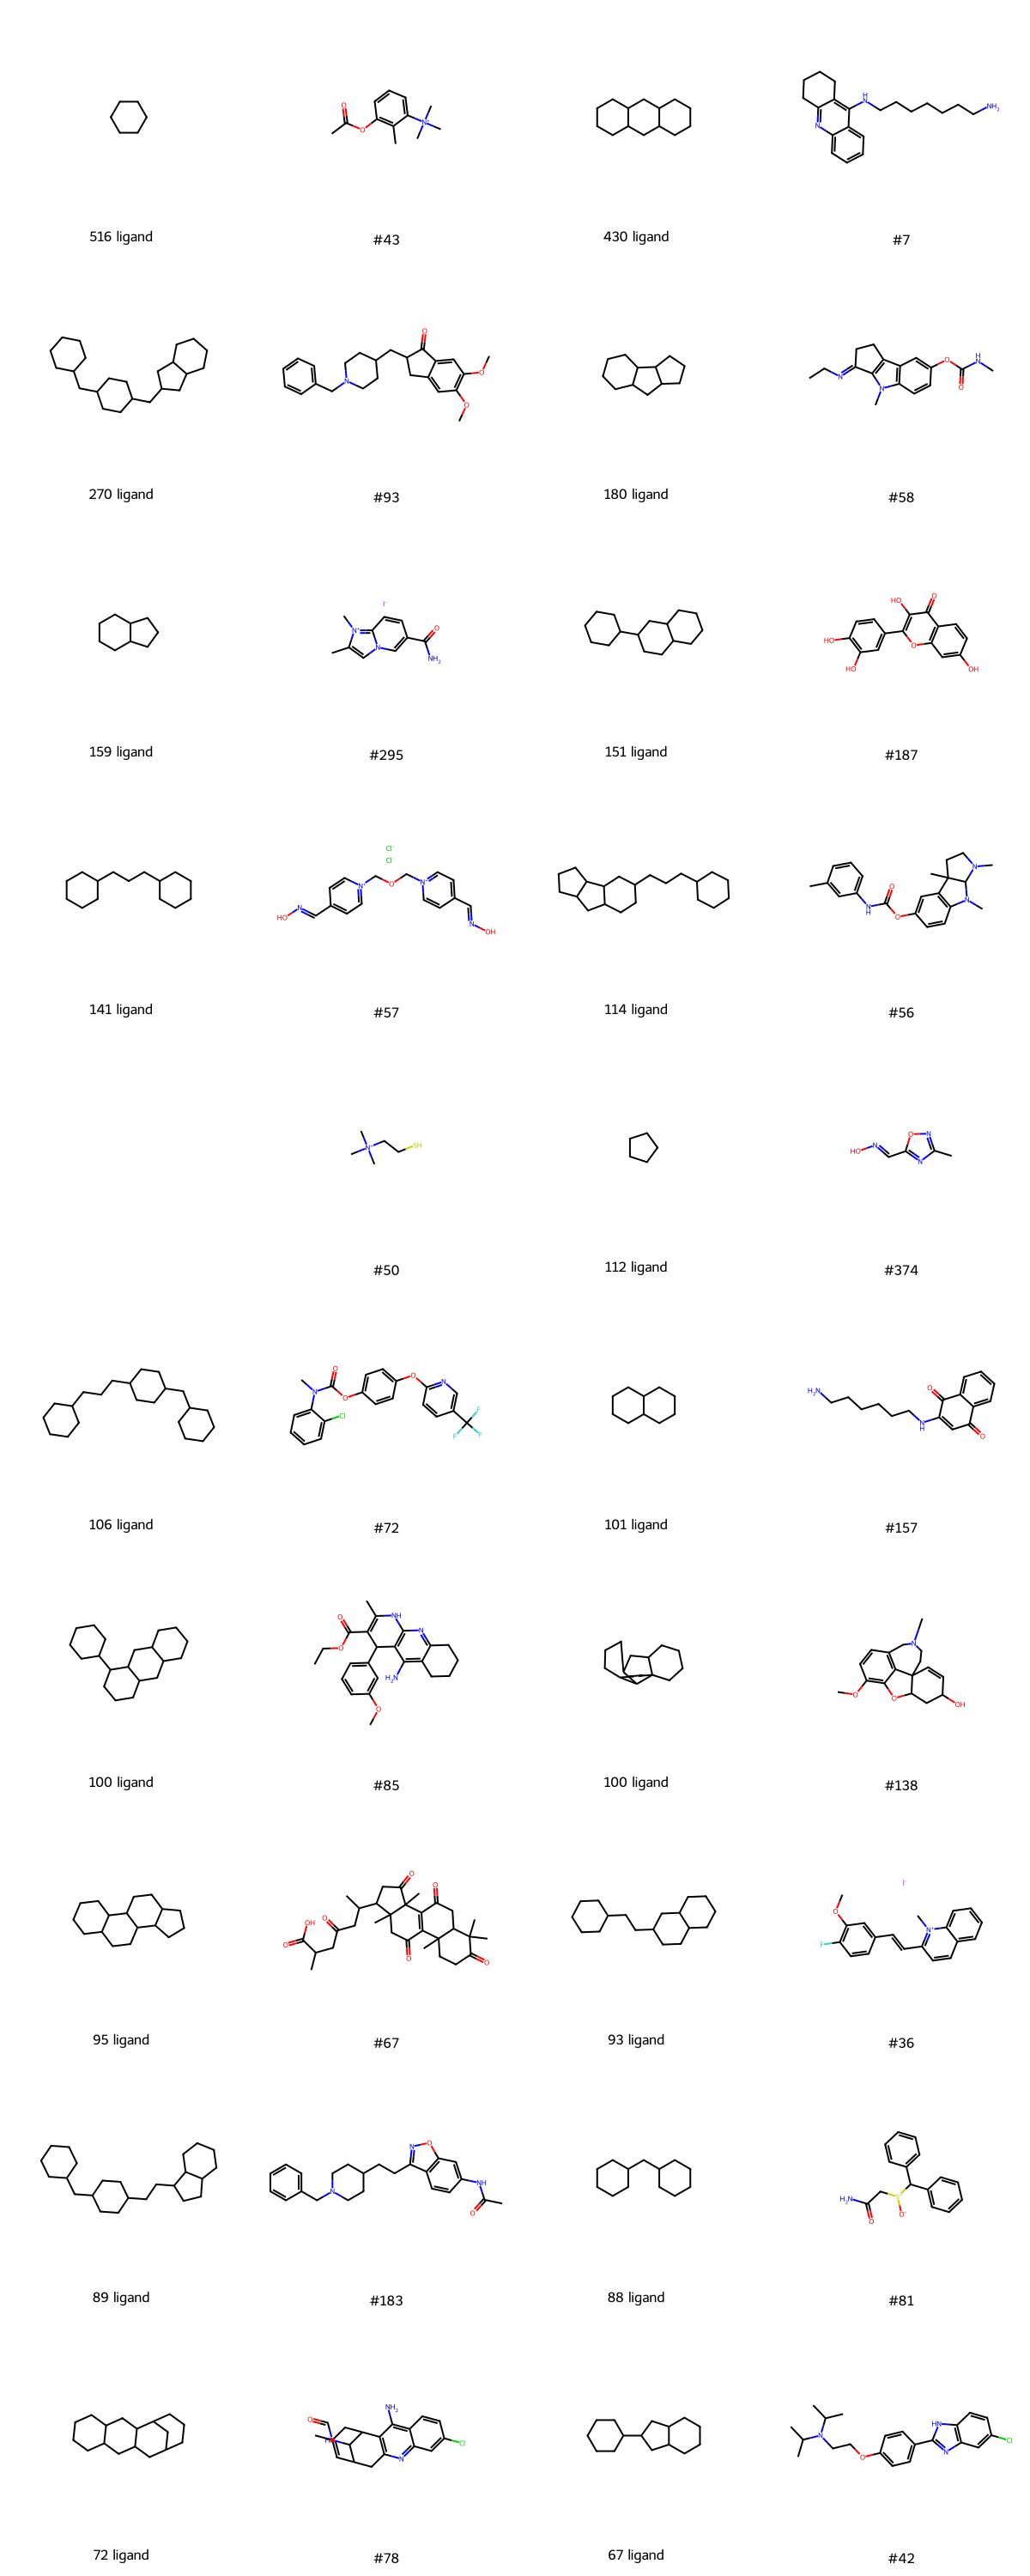

In [49]:
scaffold_representatives4visualization = []
for smi, count in scaffold_ligandcount[:20]:
    scaff_mol = Chem.MolFromSmiles(smi)
    scaff_mol.SetProp('legend', f"{count} ligandů")
    scaffold_representatives4visualization.append(scaff_mol)

    rep_mol = ache_mols[scaffold_representatives[smi]]
    rep_mol.SetProp('legend', f"#{scaffold_representatives[smi]}")
    scaffold_representatives4visualization.append(rep_mol)

Draw.MolsToGridImage(
    scaffold_representatives4visualization[:40],
    molsPerRow=4, subImgSize=(300, 300),
    legends=[mol.GetProp('legend') for mol in scaffold_representatives4visualization[:40]]
)

Vizualizace párů scaffold–ligand ukazuje top 20 nejpočetnějších
strukturních koster. Dominantní scaffoldy jsou [bicyklické/tricyklické]
systémy

Celkem unikátních scaffoldů v DrugBank: 1547


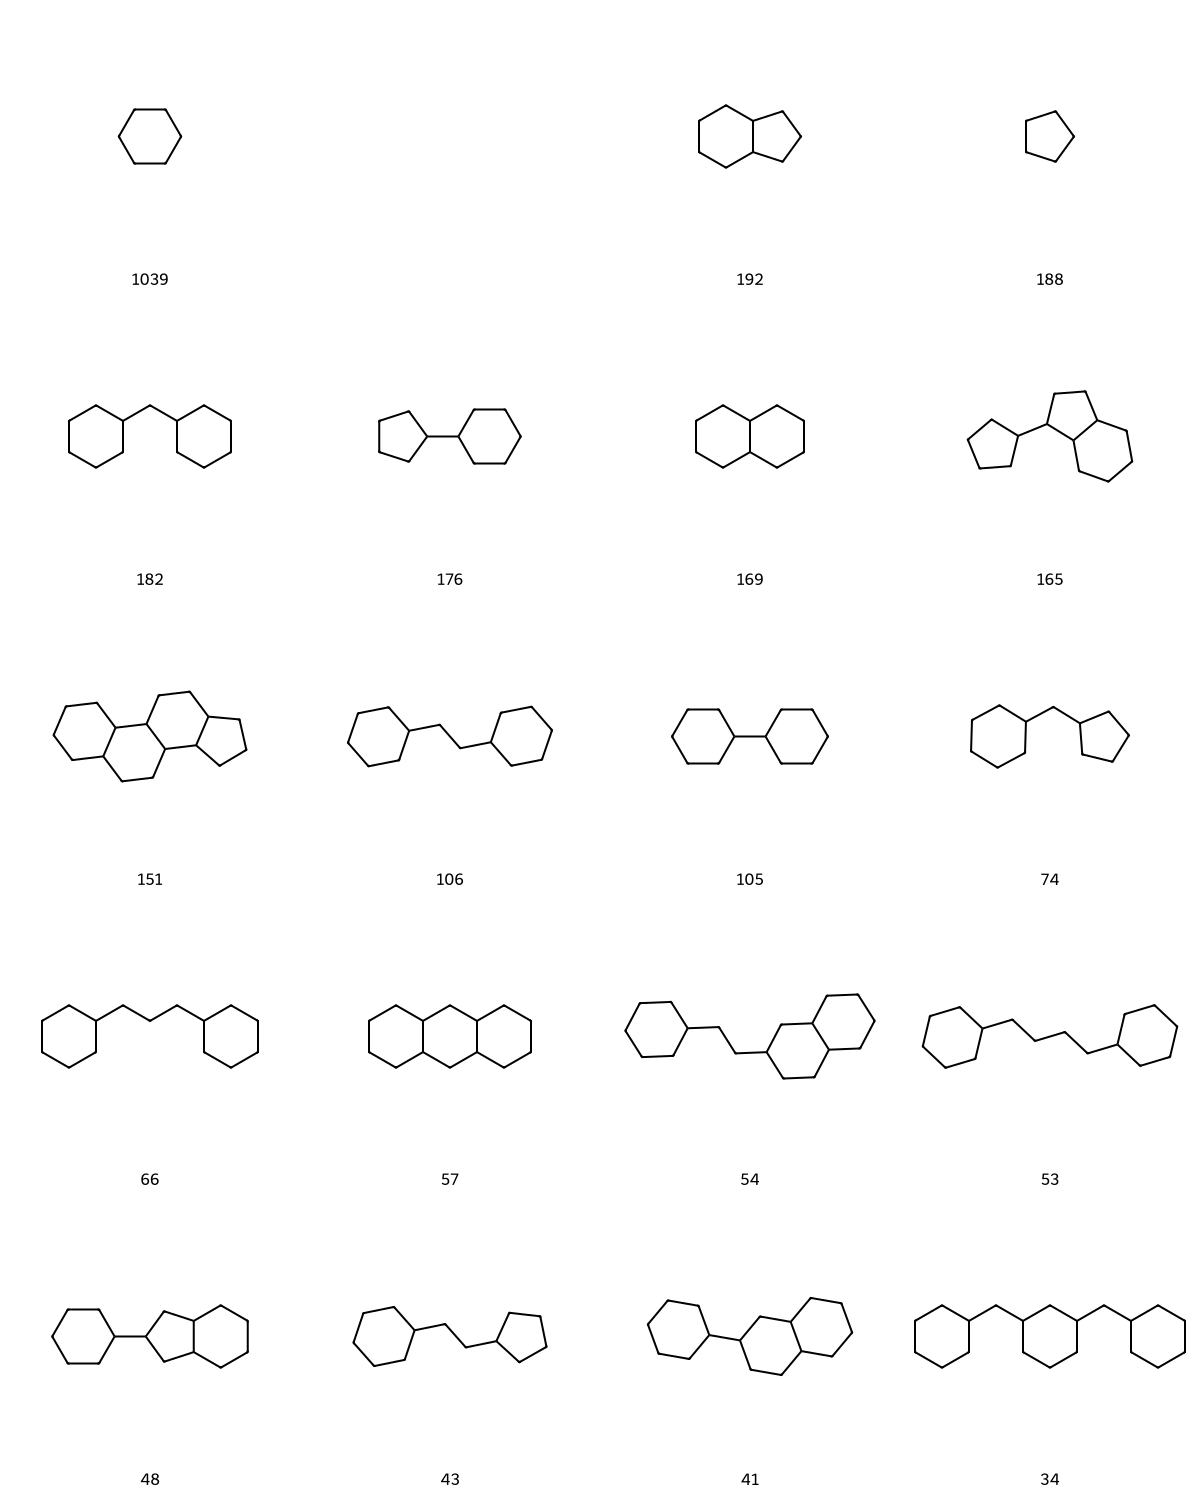

In [50]:
drugbank_mols = list(structures[structures['source'] == 'drugbank']['mol'].dropna())

drugbank_scaffolds_smiles = [(i, Chem.MolToSmiles(scaffold(mol)))
                             for i, mol in enumerate(drugbank_mols) if scaffold(mol)]

scaffolds2drugs = {smi: [] for i, smi in drugbank_scaffolds_smiles}
for i, smi in drugbank_scaffolds_smiles:
    scaffolds2drugs[smi].append(i)

scaffold_drugcount = [(smi, len(drugs)) for smi, drugs in scaffolds2drugs.items()]
scaffold_drugcount.sort(key=lambda x: x[1], reverse=True)

print(f"Celkem unikátních scaffoldů v DrugBank: {len(scaffold_drugcount)}")

Draw.MolsToGridImage(
    [Chem.MolFromSmiles(smi) for smi, count in scaffold_drugcount[:20]],
    molsPerRow=4, subImgSize=(300, 300),
    legends=[str(count) for smi, count in scaffold_drugcount[:20]]
)

Scaffold-based diversity: 1764 molekul


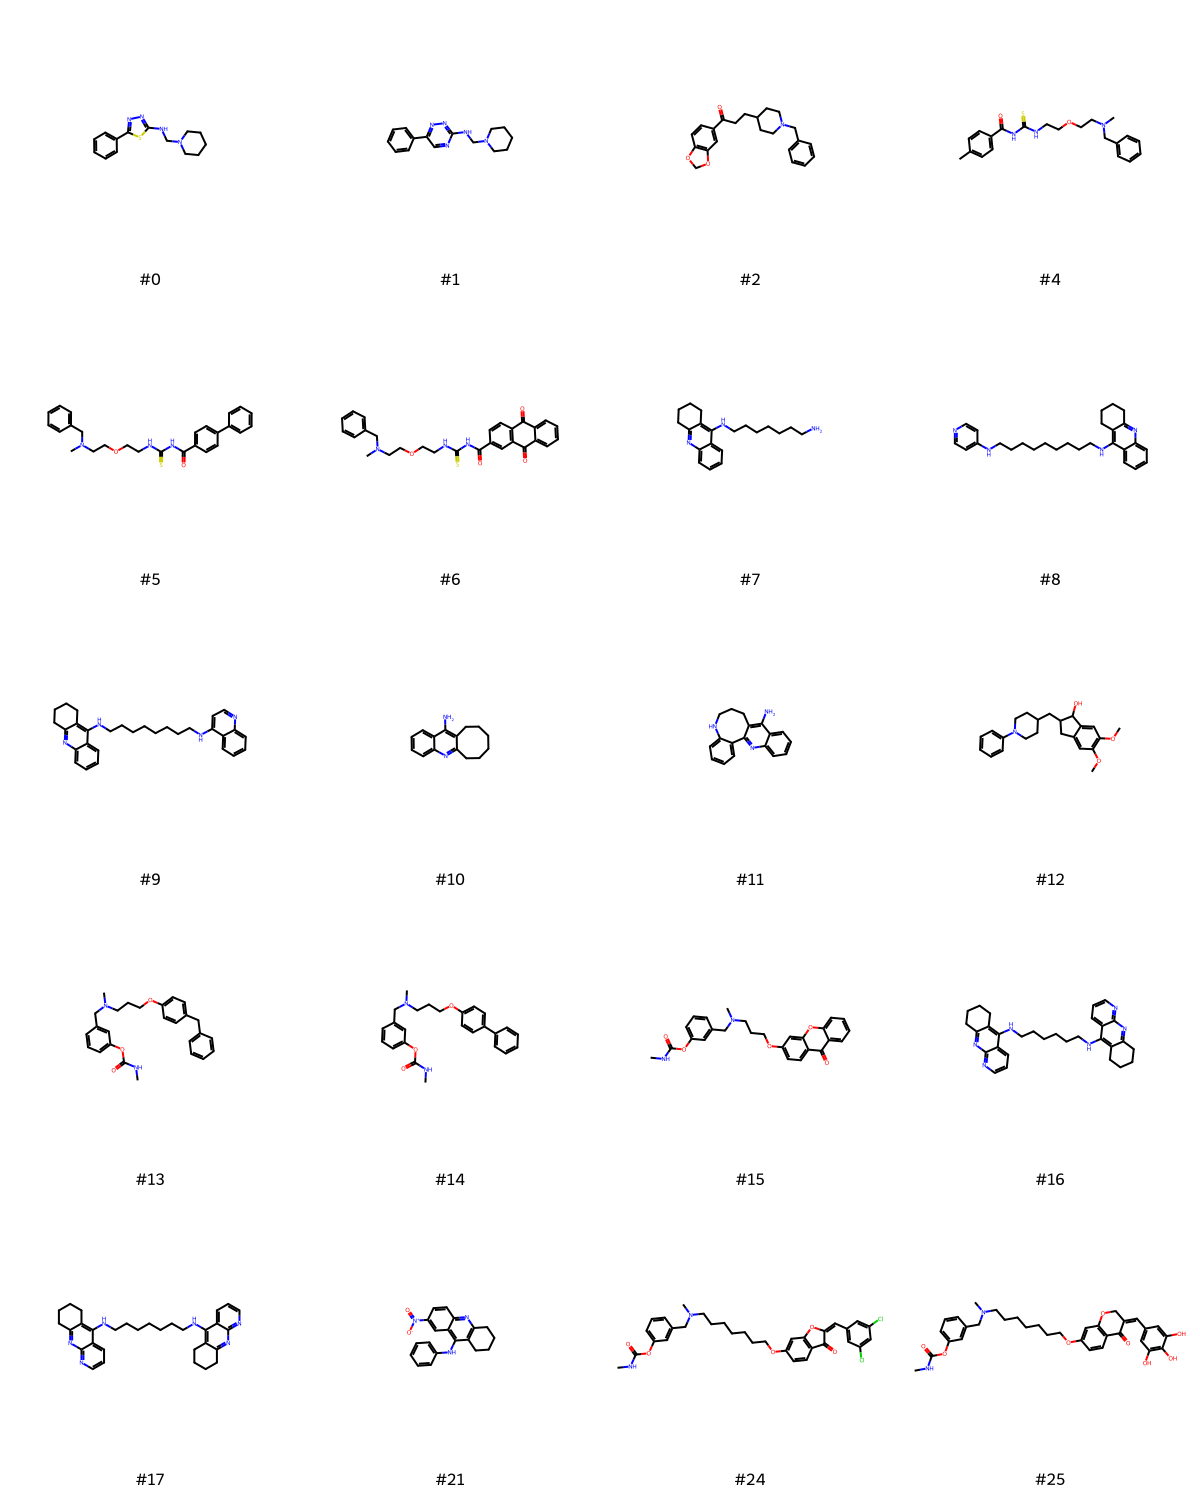

In [51]:
scaffold_based_picks = [ligs[0] for smi, ligs in scaffolds2ligands.items()]
print(f"Scaffold-based diversity: {len(scaffold_based_picks)} molekul")

Draw.MolsToGridImage(
    [ache_mols[i] for i in scaffold_based_picks[:20]],
    molsPerRow=4, subImgSize=(300, 300),
    legends=[f"#{i}" for i in scaffold_based_picks[:20]]
)

**Vizualizace scaffold-based pickingu**

Dominuje motiv dvou aromatických kruhů spojených alifatickým řetězcem
s dusíkatým linkerem.
Tento motiv odpovídá duálnímu vazebnému mechanismu AChE:
jeden kruh se váže do katalytického anionického místa (CAS),
druhý do periferního anionického místa (PAS) enzymu.

Struktury #10 a #11 ukazují kondenzované bicyklické systémy typické pro tacrinové analogy.

In [52]:
ache_scaffold_set = {smi for smi, count in scaffold_ligandcount}
drug_scaffold_set = {smi for smi, count in scaffold_drugcount}
overlap = ache_scaffold_set & drug_scaffold_set
print(f"Scaffoldy společné AChE a DrugBank: {len(overlap)} z {len(ache_scaffold_set)}")

Scaffoldy společné AChE a DrugBank: 406 z 1764


Vysoký překryv naznačuje, že AChE inhibitory sdílejí základní stavební bloky
s širší skupinou léčiv.

### Vizualizace

In [53]:
from sklearn import manifold, decomposition, preprocessing
from umap import UMAP
from scipy.spatial import distance
import numpy as np

In [54]:
structures = structures[~structures.index.duplicated(keep='first')]
if 'MQN_1' not in structures.columns:
    structures['MQN'] = structures['mol'].apply(
        lambda x: rdescriptors.MQNs_(x) if x else None
    )
    structures = structures[structures['MQN'].notna()]

    mqn_df = pd.DataFrame(structures['MQN'].tolist(),
                          index=structures.index,
                          columns=[f"MQN_{x}" for x in range(1, 43)])
    structures = structures.join(mqn_df)

print(structures.shape)

(22356, 70)


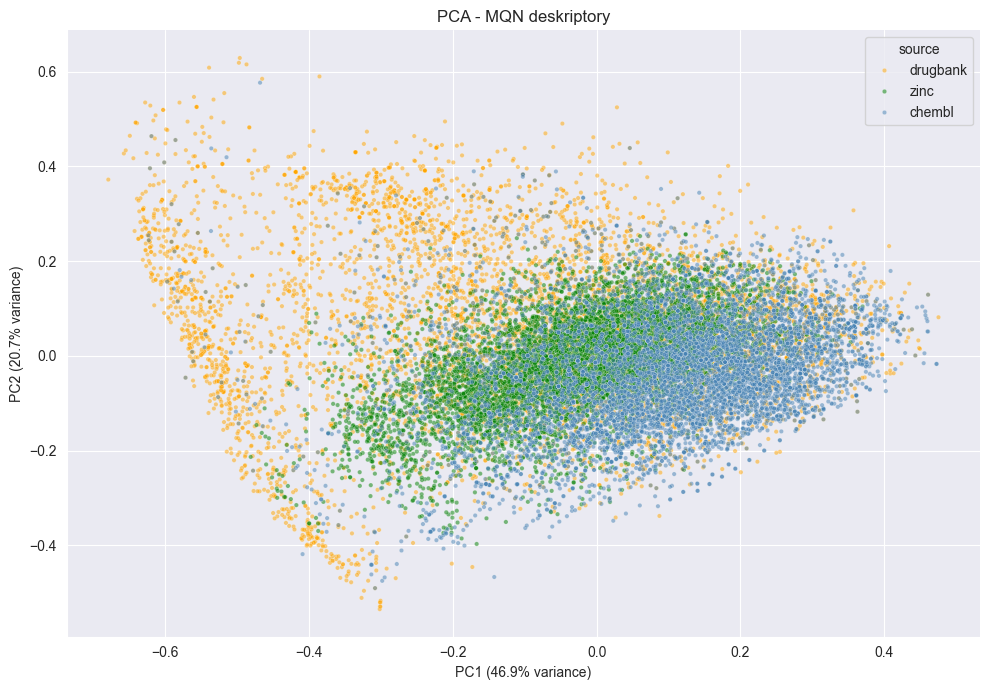

PC1 vysvětluje 46.9% variance
PC2 vysvětluje 20.7% variance
Celkem PC1+PC2: 67.6%


In [55]:
mqn_cols = [f"MQN_{x}" for x in range(1, 43)]
norm = preprocessing.normalize(structures[mqn_cols])
pca = decomposition.PCA(n_components=2)
pca.fit(norm)
pca_result = pca.fit_transform(norm)
structures['PCA_1'] = pca_result[:, 0]
structures['PCA_2'] = pca_result[:, 1]

fig, ax = plt.subplots(figsize=(10, 7))
sns.scatterplot(x='PCA_1', y='PCA_2', hue='source', data=structures, alpha=0.5, s=10, ax=ax,
                palette={'chembl': 'steelblue', 'drugbank': 'orange', 'zinc': 'green'})
ax.set_title('PCA - MQN deskriptory')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
sns.despine()
plt.tight_layout()
plt.show()

print(f"PC1 vysvětluje {pca.explained_variance_ratio_[0]:.1%} variance")
print(f"PC2 vysvětluje {pca.explained_variance_ratio_[1]:.1%} variance")
print(f"Celkem PC1+PC2: {sum(pca.explained_variance_ratio_[:2]):.1%}")

PC1 dohromady tedy zachycují 67,6 % celkové variability, což je pro 42 vstupních dimenzí velmi dobrý výsledek.

AChE inhibitory (modrá) tvoří kompaktní mrak ve střední až pravé části grafu,
zatímco DrugBank (oranžová) pokrývá širší oblast s přesahem doleva do oblasti větších nebo polarnějších molekul.
ZINC (zelená) se překrývá s AChE inhibitory ve středu,
ale zasahuje i do oblastí s nižším PC1, kde AChE inhibitory chybí.

Tři sety se překrývají, ale každý má svou preferovanou oblast prostoru.
AChE inhibitory nejsou separovány čistě, což je očekávané, protože MQN deskriptory popisují pouze atomové složení, nikoliv topologii molekuly.

C:\Projects\PNL\cdd2026\pnl\Lib\site-packages\umap\umap_.py:1887: UserWarning: gradient function is not yet implemented for jaccard distance metric; inverse_transform will be unavailable
  warn(
C:\Projects\PNL\cdd2026\pnl\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
C:\Projects\PNL\cdd2026\pnl\Lib\site-packages\pynndescent\pynndescent_.py:1241: UserWarning: Failed to correctly find n_neighbors for some samples. Results may be less than ideal. Try re-running with different parameters.
  warn(


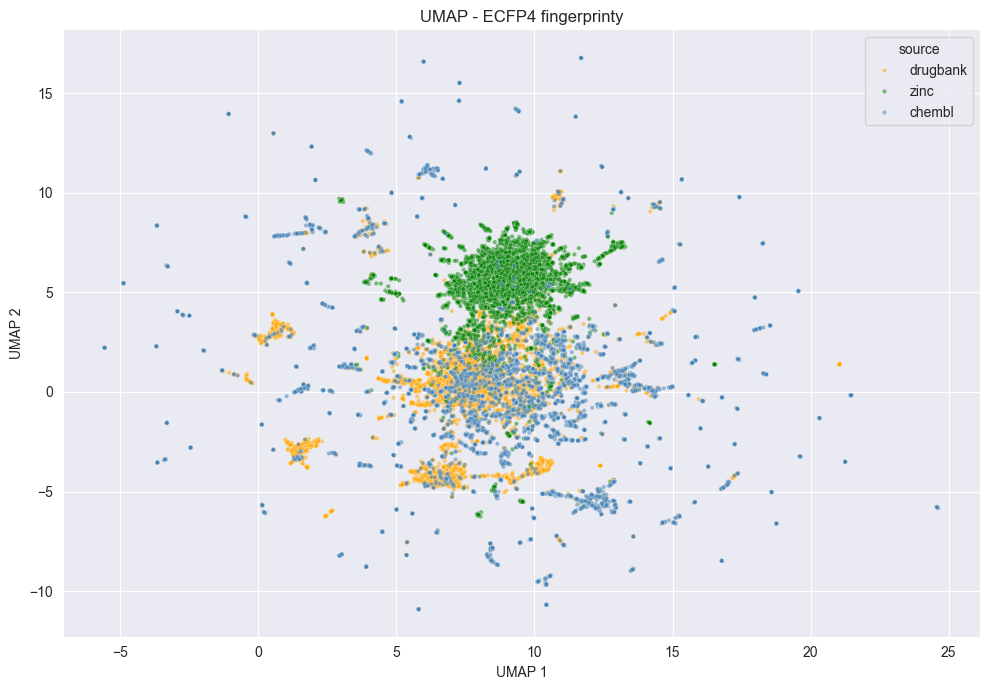

In [56]:
structures_clean = structures[structures['ECFP4'].notna()].copy()

fp_matrix = np.array(
    structures_clean['ECFP4'].apply(lambda x: list(x.ToBitString())).apply(
        lambda x: [int(b) for b in x]
    ).tolist()
)

reducer = UMAP(n_neighbors=15, min_dist=0.1, metric='jaccard', random_state=42)
embedding = reducer.fit_transform(np.array(fp_matrix))

structures_clean['umap_x'] = embedding[:, 0]
structures_clean['umap_y'] = embedding[:, 1]

fig, ax = plt.subplots(figsize=(10, 7))
sns.scatterplot(x='umap_x', y='umap_y', hue='source', data=structures_clean, alpha=0.5, s=10, ax=ax,
                palette={'chembl': 'steelblue', 'drugbank': 'orange', 'zinc': 'green'})
ax.set_title('UMAP - ECFP4 fingerprinty')
ax.set_xlabel('UMAP 1')
ax.set_ylabel('UMAP 2')
sns.despine()
plt.tight_layout()
plt.show()

Na rozdíl od PCA u UMAP ZINC tvoří kompaktní
a hustý shluk ve středu-nahoře grafu, zatímco AChE inhibitory a DrugBank jsou rozptýleny do většího prostoru s charakteristickými satelitními shluky.

Satelitní shluky po okrajích grafu jsou strukturně příbuzné skupiny molekul. Pravděpodobně série analog se stejným scaffolde.



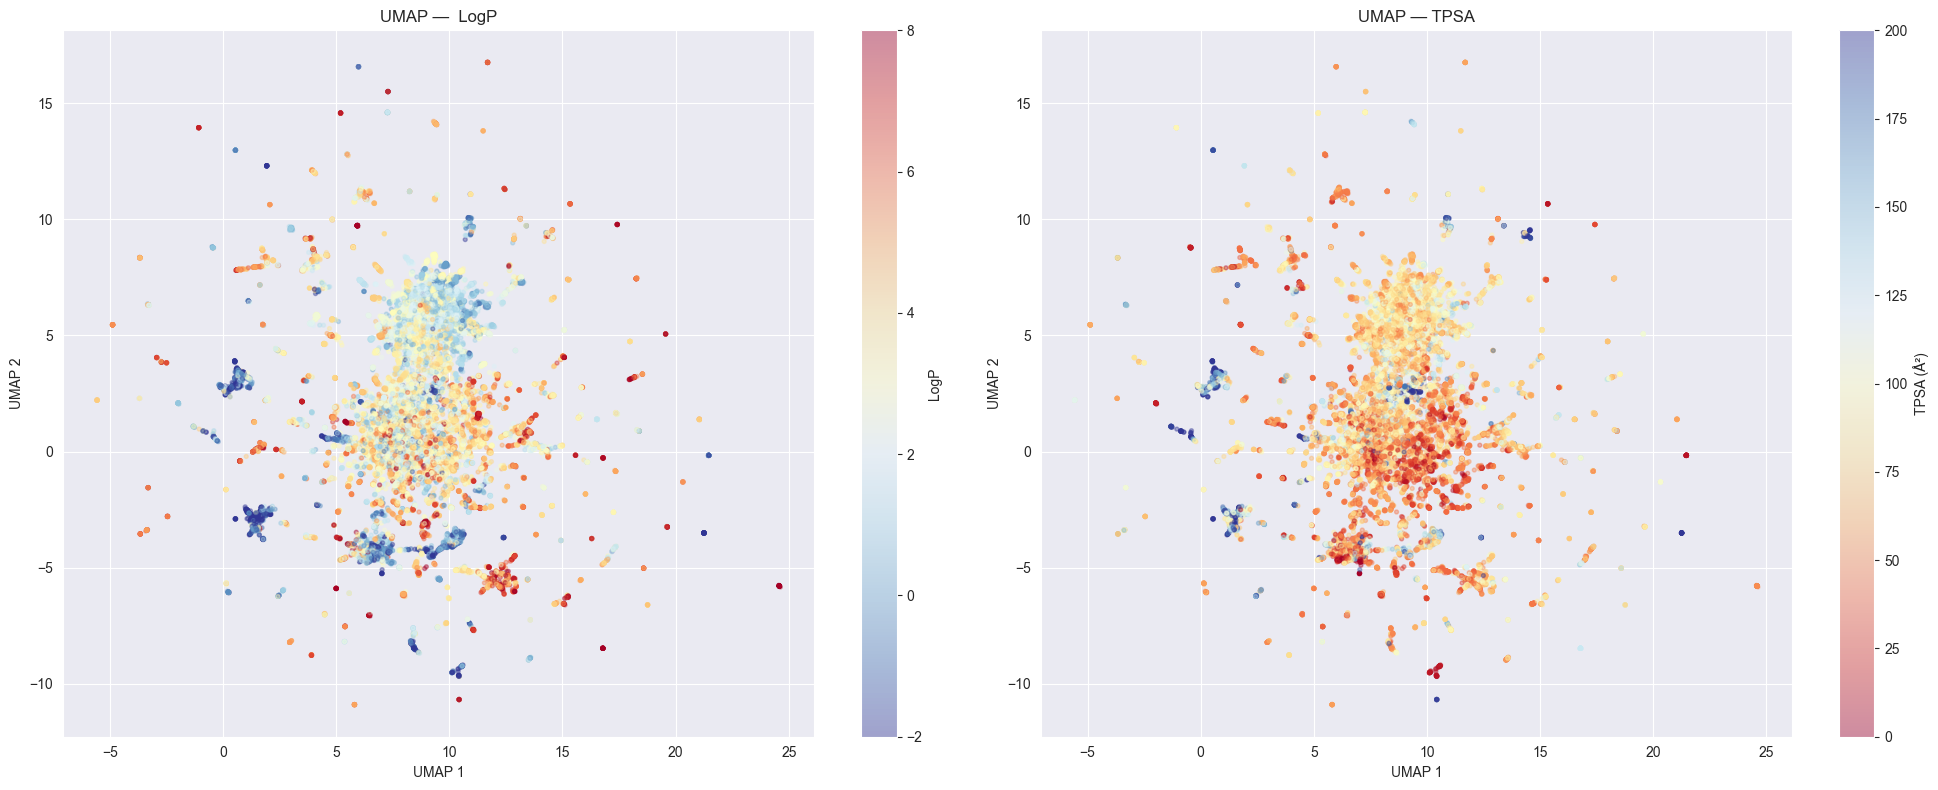

In [57]:
# UMAP colored by LogP and TPSA
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# LogP
sc1 = axes[0].scatter(
    structures_clean['umap_x'], structures_clean['umap_y'],
    c=structures_clean['logp'], cmap='RdYlBu_r',
    alpha=0.4, s=8, vmin=-2, vmax=8
)
plt.colorbar(sc1, ax=axes[0], label='LogP')
axes[0].set_title('UMAP —  LogP')
axes[0].set_xlabel('UMAP 1')
axes[0].set_ylabel('UMAP 2')

# TPSA
sc2 = axes[1].scatter(
    structures_clean['umap_x'], structures_clean['umap_y'],
    c=structures_clean['tpsa'], cmap='RdYlBu',
    alpha=0.4, s=8, vmin=0, vmax=200
)
plt.colorbar(sc2, ax=axes[1], label='TPSA (Å²)')
axes[1].set_title('UMAP — TPSA')
axes[1].set_xlabel('UMAP 1')
axes[1].set_ylabel('UMAP 2')
plt.tight_layout()
plt.show()

Interpretace: oblasti s vysokým LogP a nízkým TPSA by měly odpovídat
oblastem bohatým na AChE inhibitory

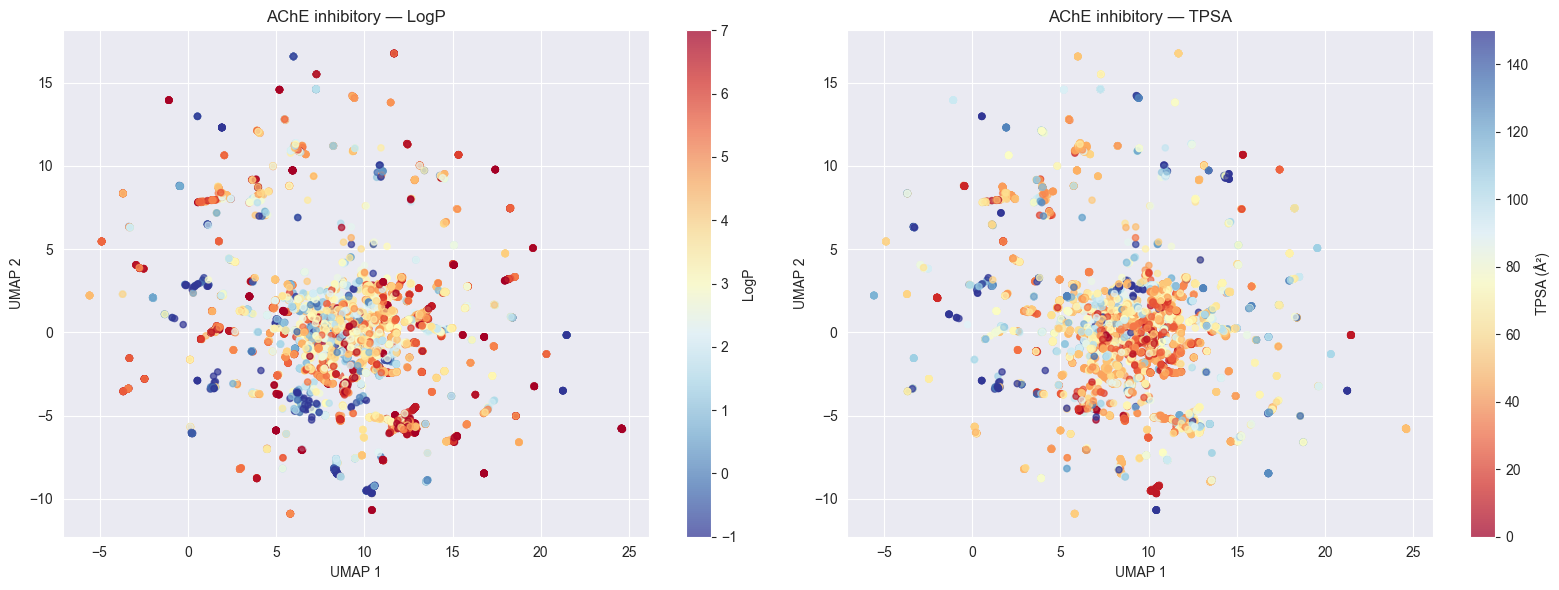

Zobrazeno 8056 AChE inhibitorů
LogP: medián=3.95, rozsah [-17.1, 16.0]
TPSA: medián=57.5 Å², rozsah [0, 778]


In [58]:
# jen pro chembl
ache_only = structures_clean[structures_clean['source'] == 'chembl'].copy()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# LogP
sc1 = axes[0].scatter(
    ache_only['umap_x'], ache_only['umap_y'],
    c=ache_only['logp'], cmap='RdYlBu_r',
    alpha=0.7, s=20, vmin=-1, vmax=7
)
plt.colorbar(sc1, ax=axes[0], label='LogP')
axes[0].set_title('AChE inhibitory — LogP', fontsize=12)
axes[0].set_xlabel('UMAP 1')
axes[0].set_ylabel('UMAP 2')

# TPSA
sc2 = axes[1].scatter(
    ache_only['umap_x'], ache_only['umap_y'],
    c=ache_only['tpsa'], cmap='RdYlBu',
    alpha=0.7, s=20, vmin=0, vmax=150
)
plt.colorbar(sc2, ax=axes[1], label='TPSA (Å²)')
axes[1].set_title('AChE inhibitory — TPSA', fontsize=12)
axes[1].set_xlabel('UMAP 1')
axes[1].set_ylabel('UMAP 2')
plt.tight_layout()
plt.show()

print(f"Zobrazeno {len(ache_only)} AChE inhibitorů")
print(
    f"LogP: medián={ache_only['logp'].median():.2f}, rozsah [{ache_only['logp'].min():.1f}, {ache_only['logp'].max():.1f}]")
print(
    f"TPSA: medián={ache_only['tpsa'].median():.1f} Å², rozsah [{ache_only['tpsa'].min():.0f}, {ache_only['tpsa'].max():.0f}]")

Hodnoty LogP jsou rozptýleny po celém prostoru bez ostrého gradientu.

Molekuly s nízkým TPSA (červená, < 40 Å²) jsou
koncentrovány ve středu a dolní části grafu, zatímco molekuly s vysokým
TPSA (modrá, > 100 Å²) jsou rozptýleny po okrajích jako izolované body.
Nízké TPSA koreluje s hustotou výskytu. Nejpočetnější strukturní třídy
AChE inhibitorů mají TPSA optimalizované pro CNS penetraci (< 75 Å²).

C:\Users\Пользователь\AppData\Local\Temp\ipykernel_2220\1936610885.py:28: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Пользователь\AppData\Local\Temp\ipykernel_2220\1936610885.py:28: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Пользователь\AppData\Local\Temp\ipykernel_2220\1936610885.py:28: UserWarning: Glyph 8325 (\N{SUBSCRIPT FIVE}) missing from font(s) Arial.
  plt.tight_layout()
C:\Projects\PNL\cdd2026\pnl\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Projects\PNL\cdd2026\pnl\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Projects\PNL\cdd2026\pnl\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8325 (\N{SUBSCR

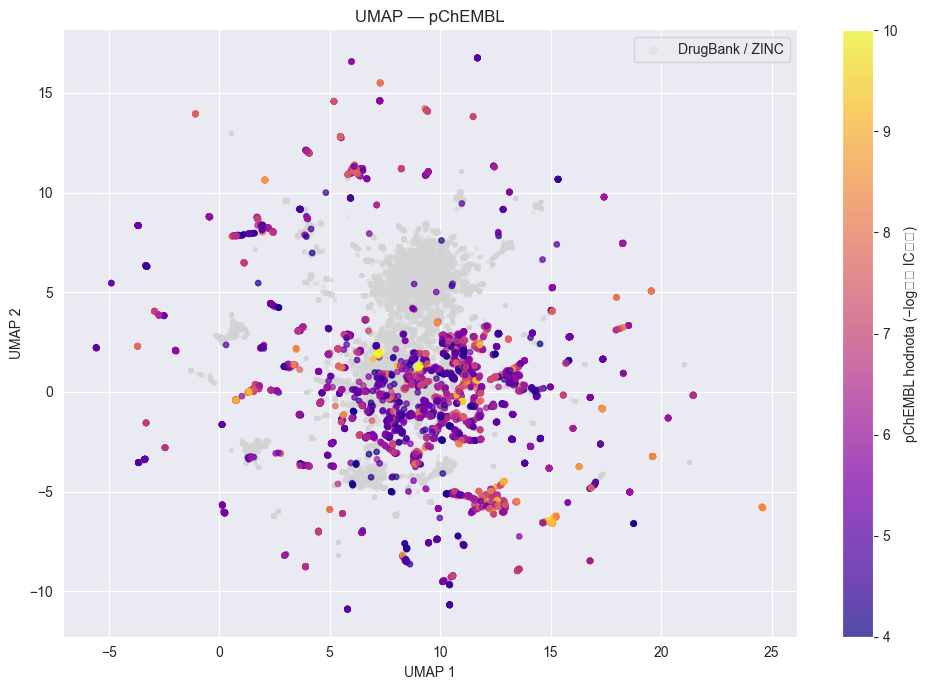

AChE inhibitory s pChEMBL hodnotou: 5549
Distribuce pChEMBL: medián=6.0, min=4.0, max=11.0


In [59]:
# UMAP colored by pChEMBL

ache_clean = structures_clean[
    (structures_clean['source'] == 'chembl') &
    (structures_clean['pChEMBL Value'].notna())
    ].copy()

fig, ax = plt.subplots(figsize=(10, 7))

# Nejprve vykreslíme DrugBank a ZINC
bg = structures_clean[structures_clean['source'] != 'chembl']
ax.scatter(bg['umap_x'], bg['umap_y'], c='lightgray', s=6, alpha=0.3,
           label='DrugBank / ZINC')

# AChE inhibitory obarvené podle pChEMBL
sc = ax.scatter(
    ache_clean['umap_x'], ache_clean['umap_y'],
    c=ache_clean['pChEMBL Value'], cmap='plasma',
    alpha=0.7, s=15, vmin=4, vmax=10
)
plt.colorbar(sc, ax=ax, label='pChEMBL hodnota (−log₁₀ IC₅₀)')

ax.set_title('UMAP — pChEMBL')
ax.set_xlabel('UMAP 1')
ax.set_ylabel('UMAP 2')
ax.legend(markerscale=2)
sns.despine()
plt.tight_layout()
plt.show()

print(f"AChE inhibitory s pChEMBL hodnotou: {len(ache_clean)}")
print(f"Distribuce pChEMBL: medián={ache_clean['pChEMBL Value'].median():.1f}, "
      f"min={ache_clean['pChEMBL Value'].min():.1f}, "
      f"max={ache_clean['pChEMBL Value'].max():.1f}")

hNejpotentní inhibitory (žlutá/zlatá, pChEMBL > 8,5,
odpovídá IC₅₀ < 3 nM) nejsou soustředěny v jedné konkrétní oblasti, ale
jsou rozptýleny v různých částech prostoru. To naznačuje, že:

1. Silná inhibice AChE není podmíněna jediným scaffoldem ani jednou oblastí
   chemického prostoru.
2. Lokální shlukování (satelity) obsahuje jak aktivní, tak méně aktivní molekuly
   ze stejné série .
3. Pro predikci pChEMBL bude muset model zachytit jemné strukturní rozdíly
   uvnitř skupin, nikoliv jen hrubé rozdělení do prostoru.

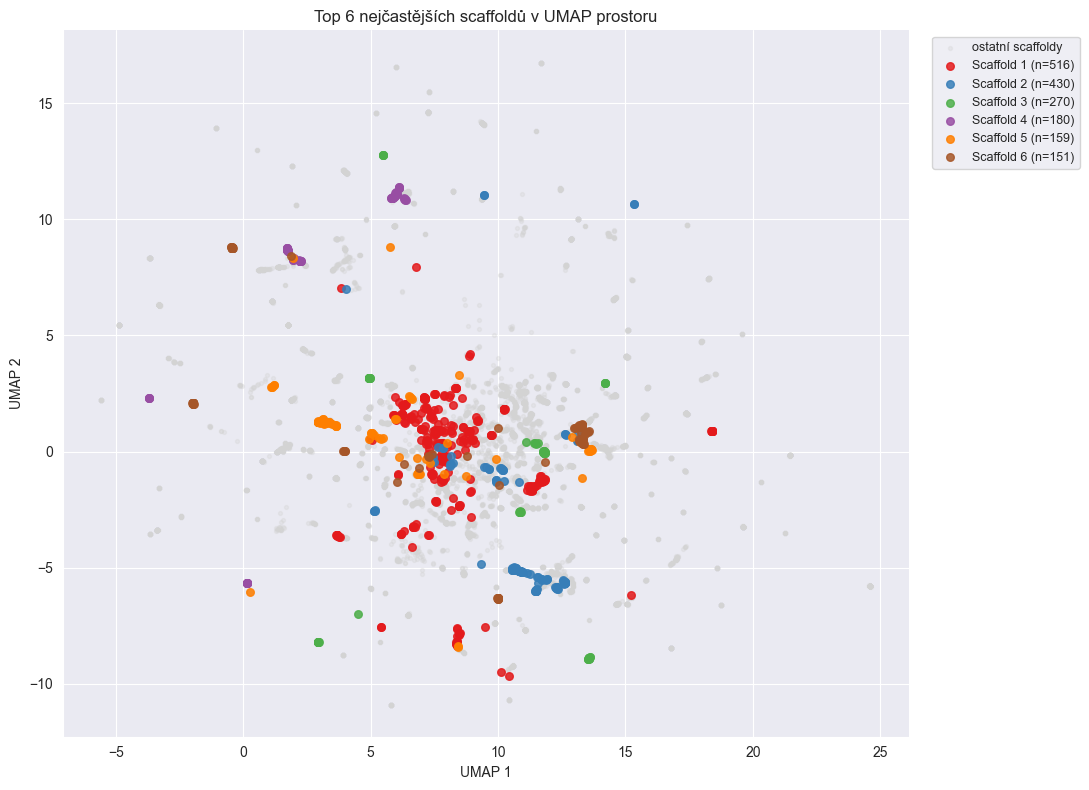

In [112]:
# Jsou molekuly se stejným scaffoldem blízko u sebe na mapě?

ache_mols_list = list(structures[structures['source'] == 'chembl']['mol'].dropna())
ache_idx       = list(structures[structures['source'] == 'chembl']['mol'].dropna().index)

scaffold_map = {}
for idx, mol in zip(ache_idx, ache_mols_list):
    s = scaffold(mol)
    if s:
        scaffold_map[idx] = Chem.MolToSmiles(s)

ache_only['scaffold_smi'] = ache_only.index.map(scaffold_map)

top6_scaffolds = [smi for smi, count in scaffold_ligandcount[:6]]
top6_labels    = [f"Scaffold {i+1} (n={count})"
                  for i, (smi, count) in enumerate(scaffold_ligandcount[:6])]

fig, ax = plt.subplots(figsize=(11, 8))

bg = ache_only[~ache_only['scaffold_smi'].isin(top6_scaffolds)]
ax.scatter(bg['umap_x'], bg['umap_y'],
           c='lightgray', s=8, alpha=0.3, label='ostatní scaffoldy')

palette = ['#e41a1c','#377eb8','#4daf4a','#984ea3','#ff7f00','#a65628']
for i, (smi, label) in enumerate(zip(top6_scaffolds, top6_labels)):
    mask = ache_only['scaffold_smi'] == smi
    ax.scatter(ache_only.loc[mask, 'umap_x'],
               ache_only.loc[mask, 'umap_y'],
               c=palette[i], s=30, alpha=0.85,
               label=label, zorder=3)

ax.set_title('Top 6 nejčastějších scaffoldů v UMAP prostoru', fontsize=12)
ax.set_xlabel('UMAP 1')
ax.set_ylabel('UMAP 2')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9)
sns.despine()
plt.tight_layout()
plt.show()

Molekuly se stejným scaffoldem se částečně shlukují.Nejostřeji scaffold 2 a 6, nejrozptýleněji scaffold 1 který je nejobecnější. 

### Clustering

In [60]:
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.model_selection import ParameterGrid
import itertools
from itertools import product


In [113]:
X = ache_only[['umap_x', 'umap_y']].values
print(f"{len(ache_only)} AChE inhibitorů")

8056 AChE inhibitorů


In [62]:
silhouette_scores = []
k_range = range(2, 20)

for k in k_range:
    km = KMeans(init='k-means++', n_clusters=k, n_init=10, random_state=42)
    labels = km.fit_predict(X)
    score = silhouette_score(X, labels, random_state=42)
    silhouette_scores.append(score)
    print(f"k={k}: silhouette={score:.4f}")

best_k = k_range[silhouette_scores.index(max(silhouette_scores))]
print(f"\nOptimální k = {best_k} (silhouette = {max(silhouette_scores):.4f})")

k=2: silhouette=0.4389
k=3: silhouette=0.3514
k=4: silhouette=0.3905
k=5: silhouette=0.3793
k=6: silhouette=0.3775
k=7: silhouette=0.3773
k=8: silhouette=0.3816
k=9: silhouette=0.3953
k=10: silhouette=0.3567
k=11: silhouette=0.3762
k=12: silhouette=0.3867
k=13: silhouette=0.3946
k=14: silhouette=0.3969
k=15: silhouette=0.3988
k=16: silhouette=0.3936
k=17: silhouette=0.3971
k=18: silhouette=0.3998
k=19: silhouette=0.4065

Optimální k = 2 (silhouette = 0.4389)


Volíme k=9 jako biologicky smysluplný počet clusterů.
Automatické maximum silhouette dávalo k=2 (příliš hrubé),
k=9 je lokální maximum a poskytuje dostatečně jemné rozdělení
pro interpretaci strukturních tříd AChE inhibitorů.

In [63]:
params = {
    'init': ['k-means++', 'random'],
    'n_init': [10, 20, 50],
    'algorithm': ['lloyd', 'elkan']
}

results = []
for init, n_init, algorithm in itertools.product(params['init'], params['n_init'], params['algorithm']):
    km = KMeans(n_clusters=9, init=init, n_init=n_init, algorithm=algorithm, random_state=42)
    labels = km.fit_predict(X)
    score = silhouette_score(X, labels, random_state=42)
    results.append((score, init, n_init, algorithm))
    print(f"init={init}, n_init={n_init}, algorithm={algorithm}: silhouette={score:.4f}")

results.sort(reverse=True)
best = results[0]
print(f"  init={best[1]}, n_init={best[2]}, algorithm={best[3]}, silhouette={best[0]:.4f}")

init=k-means++, n_init=10, algorithm=lloyd: silhouette=0.3953
init=k-means++, n_init=10, algorithm=elkan: silhouette=0.3953
init=k-means++, n_init=20, algorithm=lloyd: silhouette=0.3953
init=k-means++, n_init=20, algorithm=elkan: silhouette=0.3953
init=k-means++, n_init=50, algorithm=lloyd: silhouette=0.3849
init=k-means++, n_init=50, algorithm=elkan: silhouette=0.3849
init=random, n_init=10, algorithm=lloyd: silhouette=0.3837
init=random, n_init=10, algorithm=elkan: silhouette=0.3837
init=random, n_init=20, algorithm=lloyd: silhouette=0.3837
init=random, n_init=20, algorithm=elkan: silhouette=0.3837
init=random, n_init=50, algorithm=lloyd: silhouette=0.3850
init=random, n_init=50, algorithm=elkan: silhouette=0.3850
  init=k-means++, n_init=20, algorithm=lloyd, silhouette=0.3953


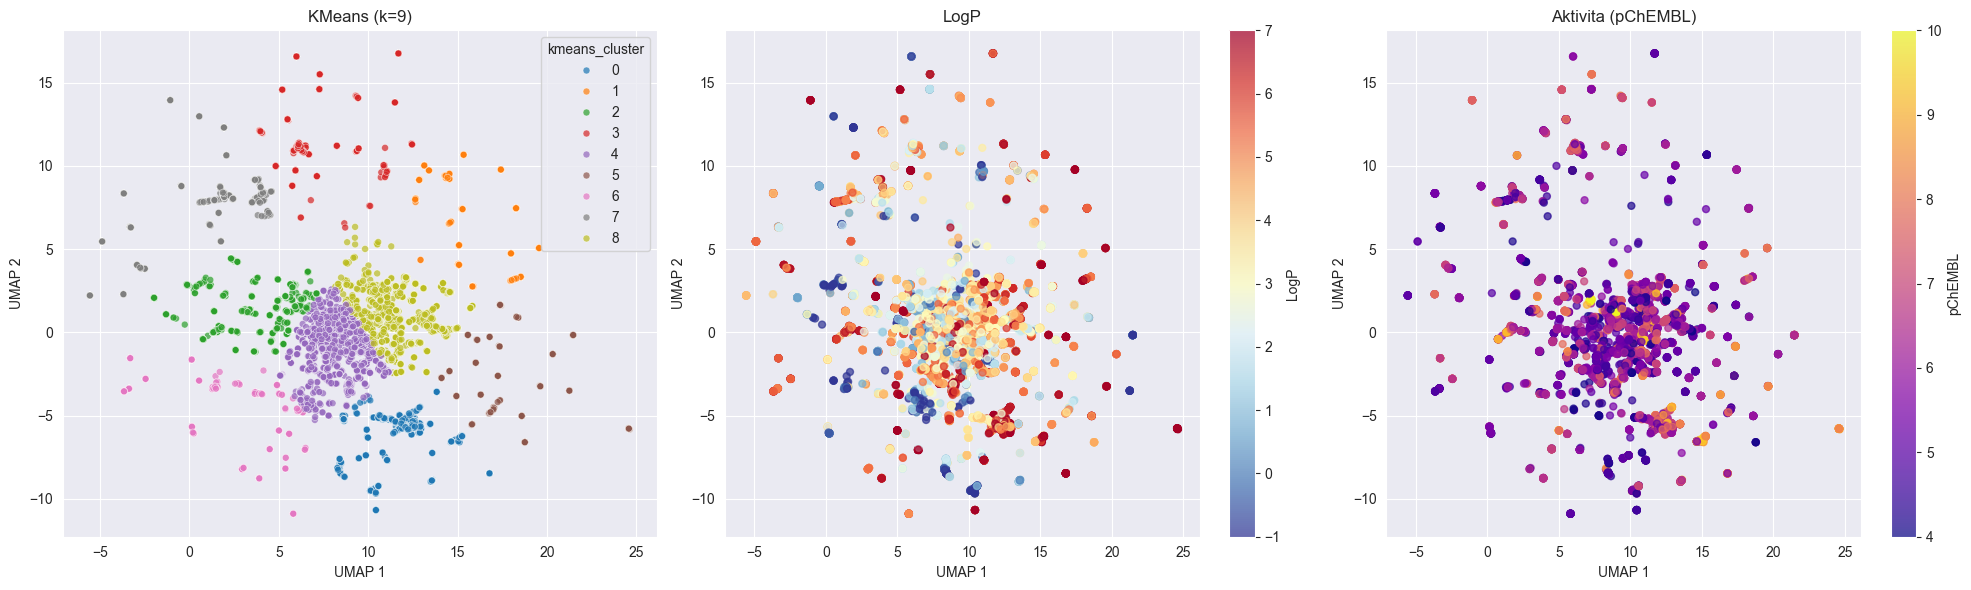

In [64]:
kmeans = KMeans(n_clusters=9, init=best[1], n_init=best[2], algorithm=best[3], random_state=42)
ache_only['kmeans_cluster'] = kmeans.fit_predict(X)

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Clustery
sns.scatterplot(x='umap_x', y='umap_y', hue='kmeans_cluster',
                data=ache_only, palette='tab10', alpha=0.7, s=25, ax=axes[0])
axes[0].set_title(f'KMeans (k=9)')
axes[0].set_xlabel('UMAP 1')
axes[0].set_ylabel('UMAP 2')

# LogP
sc1 = axes[1].scatter(ache_only['umap_x'], ache_only['umap_y'],
                      c=ache_only['logp'], cmap='RdYlBu_r',
                      alpha=0.7, s=25, vmin=-1, vmax=7)
plt.colorbar(sc1, ax=axes[1], label='LogP')
axes[1].set_title('LogP')
axes[1].set_xlabel('UMAP 1')
axes[1].set_ylabel('UMAP 2')

# pChEMBL
pchembl_valid = ache_only['pChEMBL Value'].notna()
sc2 = axes[2].scatter(ache_only.loc[pchembl_valid, 'umap_x'],
                      ache_only.loc[pchembl_valid, 'umap_y'],
                      c=ache_only.loc[pchembl_valid, 'pChEMBL Value'],
                      cmap='plasma', alpha=0.7, s=25, vmin=4, vmax=10)
plt.colorbar(sc2, ax=axes[2], label='pChEMBL')
axes[2].set_title('Aktivita (pChEMBL)')
axes[2].set_xlabel('UMAP 1')
axes[2].set_ylabel('UMAP 2')
plt.tight_layout()
plt.show()



Algoritmus KMeans úspěšně identifikoval kompaktní shluky na okrajích mapy, centrální oblast zůstala vysoce překrytá, což ukazuje spíše na spojitý medicínsko-chemický prostor než na zcela oddělené strukturní třídy. Mapování fyzikálně-chemických vlastností neukázalo žádný silný vztah mezi hodnotami LogP a příslušností k jednotlivým shlukům. Podobně i vysoce aktivní látky byly distribuovány napříč několika shluky, což potvrzuje, že inhibiční aktivita vůči AChE je spojena s různorodými strukturními scaffoldy.

In [65]:
linkages = ['ward', 'complete', 'average']
n_clusters_options = [5, 8, 10, 15, 20]

best_score = -1
best_params = None

for linkage, n_clusters in product(linkages, n_clusters_options):
    try:
        agg = AgglomerativeClustering(n_clusters=n_clusters, linkage=linkage)
        labels = agg.fit_predict(X)
        score = silhouette_score(X, labels, sample_size=5000, random_state=42)
        print(f"linkage={linkage}, k={n_clusters}: silhouette={score:.4f}")
        if score > best_score:
            best_score = score
            best_params = (linkage, n_clusters)
    except Exception as e:
        print(f"linkage={linkage}, k={n_clusters}: chyba - {e}")

print(f"\nNejlepší: linkage={best_params[0]}, k={best_params[1]}, silhouette={best_score:.4f}")

linkage=ward, k=5: silhouette=0.3553
linkage=ward, k=8: silhouette=0.3301
linkage=ward, k=10: silhouette=0.3328
linkage=ward, k=15: silhouette=0.3686
linkage=ward, k=20: silhouette=0.3748
linkage=complete, k=5: silhouette=0.2982
linkage=complete, k=8: silhouette=0.2873
linkage=complete, k=10: silhouette=0.3239
linkage=complete, k=15: silhouette=0.3181
linkage=complete, k=20: silhouette=0.2891
linkage=average, k=5: silhouette=0.3403
linkage=average, k=8: silhouette=0.3180
linkage=average, k=10: silhouette=0.3380
linkage=average, k=15: silhouette=0.3508
linkage=average, k=20: silhouette=0.3505

Nejlepší: linkage=ward, k=20, silhouette=0.3748


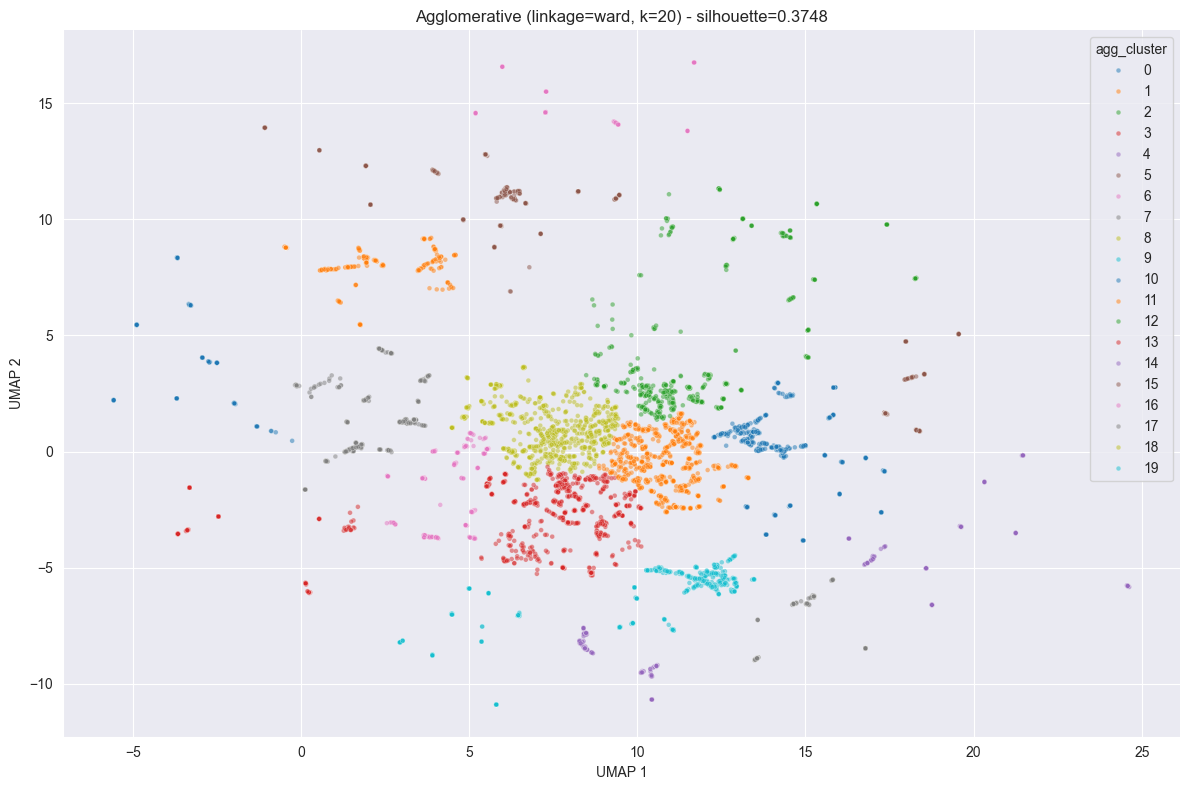

In [66]:
agg_best = AgglomerativeClustering(n_clusters=best_params[1], linkage=best_params[0])
ache_only['agg_cluster'] = agg_best.fit_predict(X)

fig, ax = plt.subplots(figsize=(12, 8))
sns.scatterplot(x='umap_x', y='umap_y', hue='agg_cluster',
                data=ache_only, alpha=0.5, ax=ax, s=12, palette='tab10')
ax.set_title(f'Agglomerative (linkage={best_params[0]}, k={best_params[1]}) - silhouette={best_score:.4f}')
ax.set_xlabel('UMAP 1')
ax.set_ylabel('UMAP 2')
sns.despine()
plt.tight_layout()
plt.show()

Hierarchické aglomerativní shlukování dosáhlo odlišného rozdělení chemického prostoru než algoritmus KMeans. Dokáže lépe kopírovat nepravidelné tvary a hustotu jednotlivých "ostrovů" v chemickém prostoru. Shluky jsou kompaktnější a lépe respektují přirozené hranice hustoty molekul.

In [114]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

In [117]:
exact_matches_db_ids = results_df[results_df['tanimoto'] == 1.0]['db_id'].unique()
structures_clean_clf = structures_clean.copy()

drop_mask = (structures_clean_clf['source'] == 'drugbank') & (structures_clean_clf.index.isin(exact_matches_db_ids))
structures_clean_clf = structures_clean_clf[~drop_mask]

X_clean = structures_clean_clf[['umap_x', 'umap_y']].values
y_clean = structures_clean_clf['source'].values

In [123]:
km_clean = KMeans(n_clusters=25, init='k-means++', n_init=10, random_state=42)
cluster_labels_clean = km_clean.fit_predict(X_clean)

idx_train, idx_test = train_test_split(
    np.arange(len(y_clean)), test_size=0.20, stratify=y_clean, random_state=42
)

cluster_to_class = {}
for cluster_id in np.unique(cluster_labels_clean):
    train_mask = (cluster_labels_clean[idx_train] == cluster_id)
    if np.sum(train_mask) > 0:
        majority_class = pd.Series(y_clean[idx_train][train_mask]).value_counts().idxmax()
        cluster_to_class[cluster_id] = majority_class
    else:
        cluster_to_class[cluster_id] = 'drugbank'

y_pred_test = [cluster_to_class[c] for c in cluster_labels_clean[idx_test]]
y_true_test = y_clean[idx_test]

y_true_named = np.where(y_true_test == 'chembl', 'Ligand (ChEMBL)', 'Non-ligand (DrugBank)')
y_pred_named = np.where(np.array(y_pred_test) == 'chembl', 'Ligand (ChEMBL)', 'Non-ligand (DrugBank)')

labels_order = ['Ligand (ChEMBL)', 'Non-ligand (DrugBank)']
print(classification_report(y_true_named, y_pred_named, target_names=labels_order))

                       precision    recall  f1-score   support

      Ligand (ChEMBL)       0.76      0.65      0.70      1612
Non-ligand (DrugBank)       0.81      0.88      0.84      2731

             accuracy                           0.80      4343
            macro avg       0.79      0.77      0.77      4343
         weighted avg       0.79      0.80      0.79      4343



Chemický prostor ligandů acetylcholinesterázy je od obecného prostoru léčiv (DrugBank) přirozeně oddělen. Úspěšnost 80 % potvrzuje, že shlukovací algoritmus dokáže efektivně rozeznat specifické strukturní vzorce typické pro AChE aktivitu i u látek, které model v trénovací fázi vůbec neviděl.

### Modelling

In [67]:
from sklearn import svm, ensemble, model_selection as ms
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (silhouette_score, mean_squared_error,
                             r2_score, root_mean_squared_error)

In [68]:
model_df = structures_clean[
    (structures_clean['source'] == 'chembl') &
    (structures_clean['pChEMBL Value'].notna())
    ].copy()
X_mqn = preprocessing.normalize(
    np.array([rdescriptors.MQNs_(mol) for mol in model_df['mol']])
)
y = model_df['pChEMBL Value'].values

print(f"Molekuly s pChEMBL hodnotou: {len(model_df)}")
print(f"pChEMBL rozsah: {model_df['pChEMBL Value'].min():.1f} – "
      f"{model_df['pChEMBL Value'].max():.1f}")
print(f"pChEMBL medián: {model_df['pChEMBL Value'].median():.2f}")

Molekuly s pChEMBL hodnotou: 5549
pChEMBL rozsah: 4.0 – 11.0
pChEMBL medián: 5.99


In [69]:
model_df['ECFP4'] = model_df['mol'].apply(
    lambda x: AllChem.GetMorganFingerprintAsBitVect(x, radius=2, nBits=1024)
    if x is not None else None
)
model_df = model_df[model_df['ECFP4'].notna()].copy()

X_ecfp = np.array([list(fp.ToBitString()) for fp in model_df['ECFP4']], dtype=int)

In [70]:
X_ecfp_train, X_ecfp_temp, y_train, y_temp = ms.train_test_split(
    X_ecfp, y, test_size=0.4, random_state=42)
X_ecfp_val, X_ecfp_test, y_val, y_test = ms.train_test_split(
    X_ecfp_temp, y_temp, test_size=0.5, random_state=42)

X_mqn_train, X_mqn_temp, _, _ = ms.train_test_split(
    X_mqn, y, test_size=0.4, random_state=42)
X_mqn_val, X_mqn_test, _, _ = ms.train_test_split(
    X_mqn_temp, y_temp, test_size=0.5, random_state=42)

In [71]:
models = {
    'RF + ECFP4': (ensemble.RandomForestRegressor(n_estimators=100, random_state=42),
                   X_ecfp_train, X_ecfp_val),
    'RF + MQN': (ensemble.RandomForestRegressor(n_estimators=100, random_state=42),
                 X_mqn_train, X_mqn_val),
    'SVM + ECFP4': (svm.SVR(kernel='rbf', C=10, gamma='scale'),
                    X_ecfp_train, X_ecfp_val),
    'SVM + MQN': (svm.SVR(kernel='rbf', C=10, gamma='scale'),
                  X_mqn_train, X_mqn_val),
}

val_results = {}
for name, (model, X_tr, X_vl) in models.items():
    model.fit(X_tr, y_train)
    y_pred = model.predict(X_vl)
    r2 = r2_score(y_val, y_pred)
    rmse = root_mean_squared_error(y_val, y_pred)
    val_results[name] = {'model': model, 'R²': r2, 'RMSE': rmse,
                         'X_test': X_ecfp_test if 'ECFP4' in name else X_mqn_test}
    print(f"{name:15s}  R²={r2:.3f}  RMSE={rmse:.3f}")

RF + ECFP4       R²=0.657  RMSE=0.774
RF + MQN         R²=0.553  RMSE=0.883
SVM + ECFP4      R²=0.699  RMSE=0.725
SVM + MQN        R²=0.218  RMSE=1.168


In [124]:
best_name = max(val_results, key=lambda k: val_results[k]['R²'])
best = val_results[best_name]
y_pred_test = best['model'].predict(best['X_test'])

r2_test = r2_score(y_test, y_pred_test)
rmse_test = mean_squared_error(y_test, y_pred_test)

print(f"Nejlepší model: {best_name}")
print(f"Validační R²:   {best['R²']:.3f}")
print(f"Testovací R²:   {r2_test:.3f}  (nezávislý set)")
print(f"Testovací RMSE: {rmse_test:.3f}")

Nejlepší model: SVM + ECFP4
Validační R²:   0.699
Testovací R²:   0.692  (nezávislý set)
Testovací RMSE: 0.519


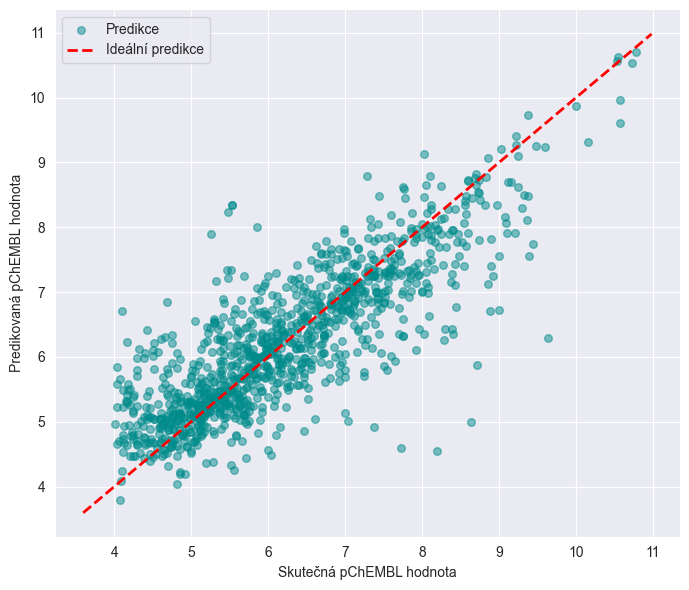

In [73]:
plt.figure(figsize=(7, 6))

y_pred_best = best['model'].predict(best['X_test'])

plt.scatter(y_test, y_pred_best, alpha=0.5, s=30, color='darkcyan', label='Predikce')

lims = [min(y_test.min(), y_pred_best.min()) - 0.2,
        max(y_test.max(), y_pred_best.max()) + 0.2]
plt.plot(lims, lims, 'r--', linewidth=2, label='Ideální predikce')

plt.xlabel('Skutečná pChEMBL hodnota')
plt.ylabel('Predikovaná pChEMBL hodnota')
plt.legend()
sns.despine()

plt.tight_layout()
plt.show()